<a href="https://colab.research.google.com/github/eyet7/Markowitz-portfolio-optimization/blob/main/financial-portfolio-theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook presents the empirical analysis conducted for the Financial Economics group assignment. We analyze a set of randomly selected S&P 500 stocks and construct efficient portfolios using the Markowitz framework and factor models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from scipy.optimize import minimize
import yfinance as yf

# Question A.1

Randomly select 10 stocks from the current S&P 500 constituents contained in the
dataset uploaded on Moodle and look at their adjusted closing prices over the last
10 years at monthly frequency. Alternatively, you can directly download the data
from Bloomberg or other providers (e.g., Yahoo Finance, Google Finance). Take
the perspective of a US investor

In [ ]:
# Connect Google and dowload the file

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/JUL_eco/sp500_monthly_stock_data.csv"
df = pd.read_csv(file_path)

# Transform the date colomn into date format
df["Date"] = pd.to_datetime(df["Date"])

# Set date as index
df.set_index("Date", inplace=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Retrieve only the adjusted price columns
adj_close_cols = [col for col in df.columns if "_Adj Close" in col]

# Extract the tickers from the column names
tickers = [col.replace("_Adj Close", "") for col in adj_close_cols]

In [ ]:
# Choose 10 random stocks
np.random.seed(42)
selected_tickers = np.random.choice(tickers, size=10, replace=False)

print("10 random stocks :")
print(selected_tickers)

10 random stocks :
['BALL' 'BX' 'ADI' 'XYL' 'BRO' 'PH' 'PODD' 'A' 'EXPD' 'INTC']


In [ ]:
# Build the price base for the 10 shares

selected_price_cols = [ticker + "_Adj Close" for ticker in selected_tickers]
Choice_10 = df[selected_price_cols].copy()

# Rename the columns to keep only the tickers
Choice_10.columns = selected_tickers

print("\nOverview of monthly adjusted prices :")
print(Choice_10.head())

print("\nstudy period :", Choice_10.index.min().date(), "à", Choice_10.index.max().date())


Overview of monthly adjusted prices :
                 BALL         BX        ADI        XYL        BRO         PH  \
Date                                                                           
2016-01-01  30.099775  16.406872  44.198284  31.692116  13.793412  82.638695   
2016-02-01  29.829550  16.219505  43.484356  32.979183  14.732734  86.074875   
2016-03-01  32.171116  17.931803  48.971844  36.207348  16.390753  95.068268   
2016-04-01  32.211723  17.541851  46.597294  36.986370  16.074839  99.296181   
2016-05-01  32.626900  16.906883  48.400967  39.535934  16.509794  98.286247   

                 PODD          A       EXPD       INTC  
Date                                                    
2016-01-01  33.180000  34.762379  39.778858  24.515545  
2016-02-01  30.639999  34.485386  40.360741  23.385399  
2016-03-01  33.160000  36.793644  43.032051  25.791693  
2016-04-01  33.299999  37.781582  43.737347  24.141350  
2016-05-01  30.020000  42.493027  42.802830  25.185772  



Data selection :

For the empirical analysis, we randomly selected ten stocks from the S&P 500 dataset using a reproducible random sampling procedure. The selected stocks are: BALL, BX, ADI, XYL, BRO, PH, PODD, A, EXPD, and INTC.

For each stock, we extracted the monthly adjusted closing prices over the full sample period from January 2016 to February 2026. Adjusted closing prices were used because they account for corporate actions such as stock splits and dividend payments, providing a more accurate measure of the true evolution of stock prices over time.

The selected companies belong to different industries, including technology, industrials, financial services, healthcare, and logistics. This sectoral diversity is useful because it provides an initial level of diversification within the sample of assets.

Figure 1 presents the evolution of the adjusted closing prices for the ten selected stocks over the sample period.

In [ ]:
# Save the result in google drive
output_path = "/content/drive/MyDrive/JUL_eco/selected_10_stocks_prices.csv"
Choice_10.to_csv(output_path)

print(f"\nFile saved in : {output_path}")


File saved in : /content/drive/MyDrive/JUL_eco/selected_10_stocks_prices.csv


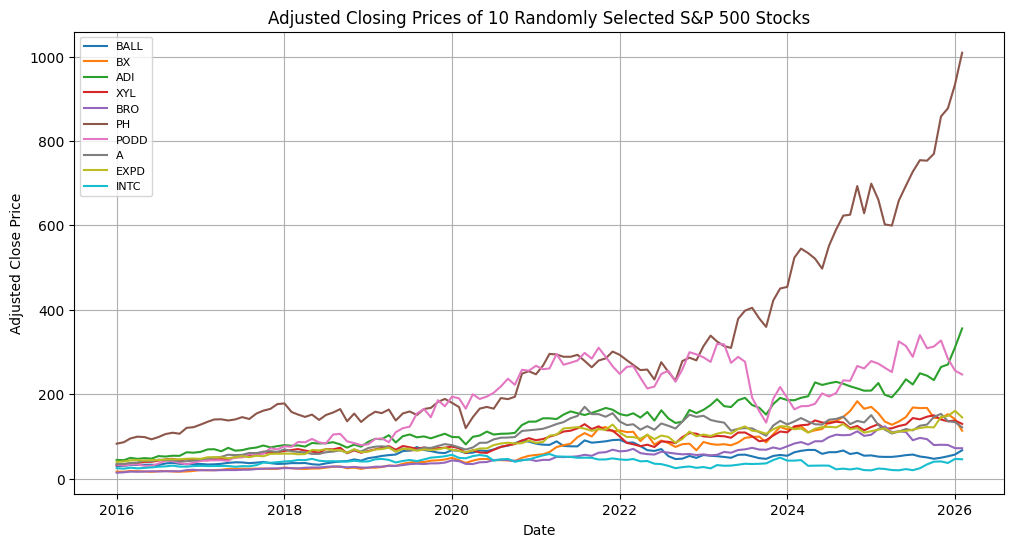

In [ ]:
# Graph of prices
plt.figure(figsize=(12, 6))

for col in Choice_10.columns:
    plt.plot(Choice_10.index, Choice_10[col], label=col)

plt.title("Adjusted Closing Prices of 10 Randomly Selected S&P 500 Stocks")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()

Adjusted closing prices of the randomly selected S&P 500 stocks (2016–2026) :

Over the sample period, most stocks exhibit an overall upward trend, reflecting the long-term growth of the U.S. equity market. However, the magnitude of price increases differs substantially across firms. Some stocks display stronger growth and higher volatility than others.

For example, certain firms experienced significant price appreciation over the period, indicating strong market performance, while others show more moderate growth. The dispersion in price levels and trajectories across stocks highlights the heterogeneity in company performance and risk profiles.

This variability across assets is important for portfolio analysis, as it creates opportunities for diversification when constructing portfolios in the subsequent parts of the project.

# Question A.2
Compute arithmetic returns of the selected stocks as well as their mean, variance-
covariance and the correlation matrices, and provide some comments (e.g., on in-
dustry diversification, life stage of the companies, etc.)

In [ ]:
# Calculating monthly arithmetic returns

Our_return = Choice_10.pct_change().dropna()

print("\nMonthly returns :")
print(Our_return.head())



Monthly returns :
                BALL        BX       ADI       XYL       BRO        PH  \
Date                                                                     
2016-02-01 -0.008978 -0.011420 -0.016153  0.040612  0.068099  0.041581   
2016-03-01  0.078498  0.105570  0.126195  0.097885  0.112540  0.104483   
2016-04-01  0.001262 -0.021746 -0.048488  0.021516 -0.019274  0.044472   
2016-05-01  0.012889 -0.036197  0.038708  0.068933  0.027058 -0.010171   
2016-06-01  0.001675 -0.063001 -0.024760  0.003351  0.042746 -0.053801   

                PODD         A      EXPD      INTC  
Date                                                
2016-02-01 -0.076552 -0.007968  0.014628 -0.046099  
2016-03-01  0.082245  0.066934  0.066186  0.102897  
2016-04-01  0.004222  0.026851  0.016390 -0.063987  
2016-05-01 -0.098498  0.124702 -0.021367  0.043263  
2016-06-01  0.007328 -0.033340  0.018422  0.047272  


In [ ]:
# Statistics requested in A.2
mean_returns = Our_return.mean()
cov_matrix = Our_return.cov()
corr_matrix = Our_return.corr()

print("\nMonthly average returns :")
print(mean_returns)

print("\nVariance-covariance matrix :")
print(cov_matrix)

print("\nCorrelation matrix :")
print(corr_matrix)


Monthly average returns :
BALL    0.009342
BX      0.020555
ADI     0.020409
XYL     0.014116
BRO     0.015803
PH      0.024313
PODD    0.023036
A       0.013058
EXPD    0.012940
INTC    0.010592
dtype: float64

Variance-covariance matrix :
          BALL        BX       ADI       XYL       BRO        PH      PODD  \
BALL  0.005412  0.002677  0.001848  0.002118  0.001642  0.002735  0.002176   
BX    0.002677  0.009017  0.003114  0.002873  0.002213  0.004363  0.003449   
ADI   0.001848  0.003114  0.006248  0.002565  0.001308  0.004160  0.002248   
XYL   0.002118  0.002873  0.002565  0.004845  0.001337  0.003497  0.002664   
BRO   0.001642  0.002213  0.001308  0.001337  0.004180  0.001802  0.001317   
PH    0.002735  0.004363  0.004160  0.003497  0.001802  0.006912  0.002544   
PODD  0.002176  0.003449  0.002248  0.002664  0.001317  0.002544  0.013318   
A     0.002135  0.003649  0.002633  0.003183  0.001165  0.003604  0.003367   
EXPD  0.001034  0.002518  0.002723  0.002448  0.001381  

Mean returns, as well as the variance–covariance and correlation matrices, provide a summary of the statistical relationships between the selected stocks. While the covariance matrix measures how the returns vary together, the correlation matrix makes it easier to interpret. We now examine these results in the following results

In [ ]:
#we add the monthly standard deviation
summary_stats = pd.DataFrame({
    "Mean monthly return": mean_returns,
    "Monthly volatility (std dev)": Our_return.std(),
    "Min monthly return": Our_return.min(),
    "Max monthly return": Our_return.max()
})

# we sort by decreasing average yield
summary_stats = summary_stats.sort_values(by="Mean monthly return", ascending=False)

print("\nStatistical summary of the 10 stocks:")
print(summary_stats)


Statistical summary of the 10 stocks:
      Mean monthly return  Monthly volatility (std dev)  Min monthly return  \
PH               0.024313                      0.083139           -0.294935   
PODD             0.023036                      0.115402           -0.307281   
BX               0.020555                      0.094956           -0.225486   
ADI              0.020409                      0.079045           -0.173437   
BRO              0.015803                      0.064653           -0.175882   
XYL              0.014116                      0.069605           -0.178916   
A                0.013058                      0.073771           -0.155755   
EXPD             0.012940                      0.066987           -0.147516   
INTC             0.010592                      0.105089           -0.310165   
BALL             0.009342                      0.073567           -0.239853   

      Max monthly return  
PH              0.282684  
PODD            0.426341  
BX        

The summary statistics highlight noticeable differences in both returns and risk among the ten selected stocks. PH, PODD, and BX stand out with the highest average monthly returns, while BALL and INTC show comparatively lower performance. We now look at the volatility. PODD and INTC seem to be the most volatile, whereas BRO, A, and EXPD appear relatively more stable. The wide range between minimum and maximum monthly returns, especially for PODD and INTC, points to significant market fluctuations during the sample period. These variations in return and risk indicate that combining these stocks in a portfolio could offer diversification benefits.

In [ ]:
# Annualization

summary_stats_annualized = pd.DataFrame({
    "Annualized mean return": mean_returns * 12,
    "Annualized volatility": Our_return.std() * np.sqrt(12)
}).sort_values(by="Annualized mean return", ascending=False)

print("\nAnnualized summary  :")
print(summary_stats_annualized)


Annualized summary  :
      Annualized mean return  Annualized volatility
PH                  0.291757               0.288001
PODD                0.276428               0.399765
BX                  0.246665               0.328936
ADI                 0.244911               0.273821
BRO                 0.189637               0.223966
XYL                 0.169386               0.241119
A                   0.156693               0.255549
EXPD                0.155286               0.232050
INTC                0.127102               0.364039
BALL                0.112107               0.254844


When annualizing the results, PH and PODD exhibit the highest expected annual returns, close to 29% and 28% respectively. However, these stocks also show relatively high volatility (PODD and INTC in particular) which mean greater risk. In contrast, stocks such as BRO and EXPD show lower annual returns but also more moderate volatility, suggesting more stable performance.

In [ ]:
# Saving results

Our_return.to_csv("A2_monthly_Our_returnstocks.csv")
mean_returns.to_csv("A2_mean_returns.csv", header=["Mean monthly return"])
cov_matrix.to_csv("A2_covariance_matrix.csv")
corr_matrix.to_csv("A2_correlation_matrix.csv")
summary_stats.to_csv("A2_summary_statistics.csv")


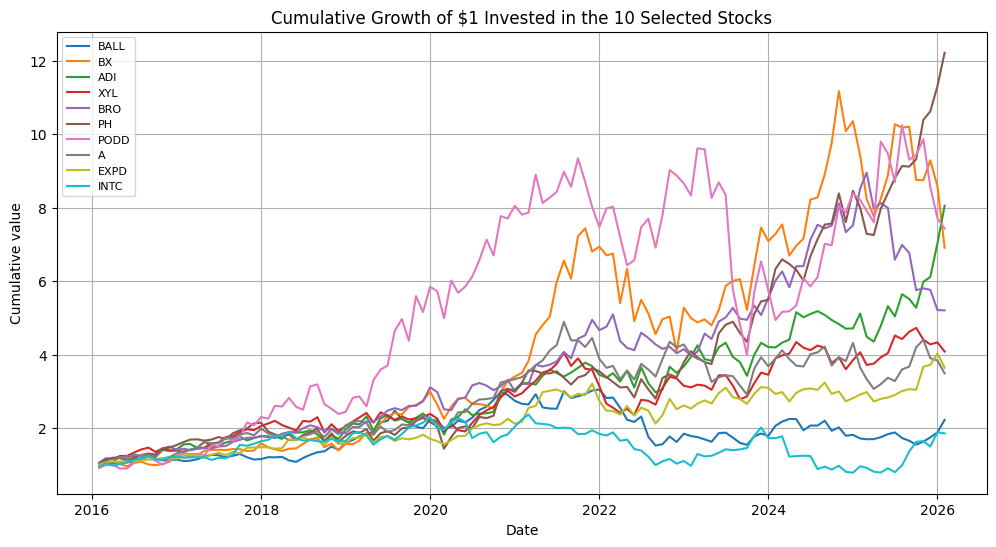

In [ ]:
# Evolution of cumulative returns

cumulative_returns = (1 + Our_return).cumprod()

plt.figure(figsize=(12, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Growth of $1 Invested in the 10 Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative value")
plt.legend(fontsize=8, loc="best")
plt.grid(True)
plt.show()


The cumulative return chart shows how a $1 investment would have grown over time for each of the ten selected stocks. While the stocks tend to follow similar trends during certain market periods, their long-term performance varies quite a lot. For example, BX, PH, and PODD show strong growth and clearly outperform the others, while BALL and INTC have more moderate or unstable returns. This shows that even in the same market environment, individual stocks can perform very differently over time.

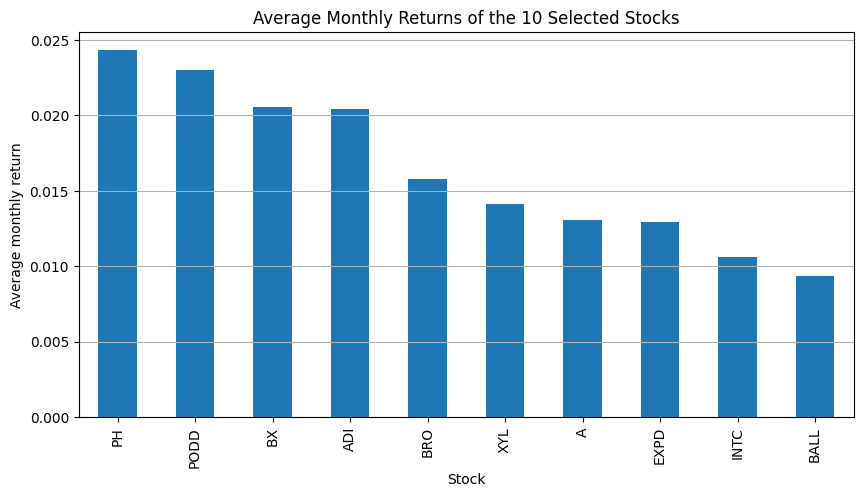

In [ ]:
# Bar chart of monthly average returns

plt.figure(figsize=(10, 5))
mean_returns.sort_values(ascending=False).plot(kind="bar")
plt.title("Average Monthly Returns of the 10 Selected Stocks")
plt.xlabel("Stock")
plt.ylabel("Average monthly return")
plt.grid(axis="y")
plt.show()

The bar chart shows the average monthly returns for the ten selected stocks. PH and PODD have the highest average returns, followed by BX and ADI, reflecting stronger performance over the period. On the other hand, INTC and BALL show the lowest returns. This spread clearly illustrates that even within the same market, individual stocks can deliver very different levels of performance.

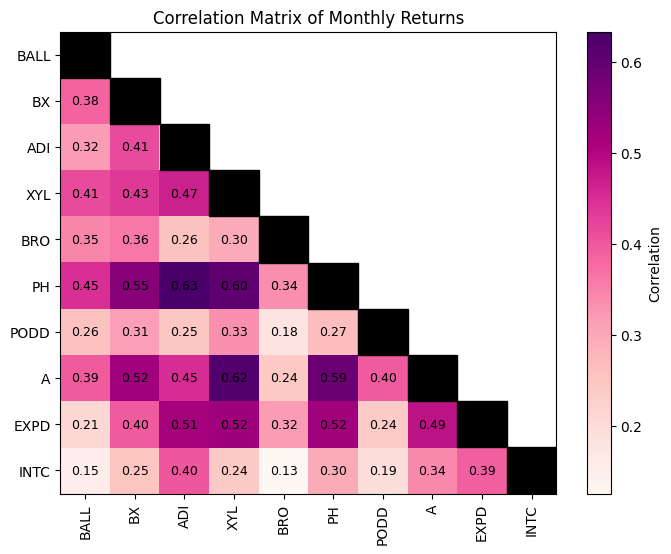

In [ ]:
# Heatmap of correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_lower = corr_matrix.mask(mask)

plt.figure(figsize=(8,6))

# Heatmap
plt.imshow(corr_lower, cmap="RdPu", aspect="auto")

plt.colorbar(label="Correlation")

# Diagonal in black
for i in range(len(corr_matrix)):
    plt.gca().add_patch(
        plt.Rectangle((i-0.5, i-0.5), 1, 1, color="black")
    )


for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        if not mask[i, j]:
            value = corr_matrix.iloc[i, j]
            plt.text(j, i, f"{value:.2f}",
                     ha="center", va="center",
                     color="black", fontsize=9)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation Matrix of Monthly Returns")

plt.show()

The correlation heatmap shows how the monthly returns of the ten selected stocks are related. Most of the correlations are positive but moderate (from about 0.2 to 0.7). That means that  the stocks tend to move in the same direction, but not perfectly. For example, PH with ADI or A, show strong correlations : they have quite similar sensitivity to market movements. Overall, these imperfect positive correlations suggest that combining these stocks in a portfolio could provide diversification benefits.

In [ ]:
# most and least correlated pairs

pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        stock_i = corr_matrix.columns[i]
        stock_j = corr_matrix.columns[j]
        corr_ij = corr_matrix.iloc[i, j]
        pairs.append((stock_i, stock_j, corr_ij))

pairs_df = pd.DataFrame(pairs, columns=["Stock 1", "Stock 2", "Correlation"])

most_correlated = pairs_df.sort_values(by="Correlation", ascending=False).head(5)
least_correlated = pairs_df.sort_values(by="Correlation", ascending=True).head(5)

print("\nTop 5 most correlated pairs :")
print(most_correlated)

print("\nTop 5 least correlated pairs :")
print(least_correlated)


Top 5 most correlated pairs :
   Stock 1 Stock 2  Correlation
19     ADI      PH     0.633008
27     XYL       A     0.619883
25     XYL      PH     0.604249
36      PH       A     0.587612
12      BX      PH     0.552670

Top 5 least correlated pairs :
   Stock 1 Stock 2  Correlation
34     BRO    INTC     0.125390
8     BALL    INTC     0.151353
31     BRO    PODD     0.176526
41    PODD    INTC     0.193316
7     BALL    EXPD     0.209888


The most correlated pairs, such as ADI–PH and XYL–A, tend to move similarly over time. But some pairs like BRO–INTC or BALL–INTC show low positive correlations. These pairs offer better diversification potential in a portfolio.

# Question B.1

Following the Markowitz approach, numerically determine the minimum variance
frontier in at least 20 points. Highlight the efficient part of the frontier

In [ ]:
# Inputs from A.2
mean_returns = Our_return.mean().values
cov_matrix = Our_return.cov().values
n_assets = len(mean_returns)

In [ ]:
# Portfolio functions

def portfolio_return(weights):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def portfolio_variance(weights):
    return np.dot(weights.T, np.dot(cov_matrix, weights))


In [ ]:
# Variance minimization for a target return

def efficient_portfolio(target_return):

    constraints = (
        {'type':'eq','fun': lambda w: np.sum(w) - 1},
        {'type':'eq','fun': lambda w: portfolio_return(w) - target_return}
    )

    initial_weights = np.ones(n_assets) / n_assets

    result = minimize(
        portfolio_variance,
        initial_weights,
        method='SLSQP',
        constraints=constraints
    )

    return result.x

For each target level of expected return, we solve a constrained optimization problem that minimizes portfolio variance. The first constraint imposes full investment, meaning that portfolio weights must sum to one. The second constraint ensures that the portfolio reaches the required target return.

In [ ]:
# Build the frontier

target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

frontier_returns = []
frontier_volatility = []

for target in target_returns:

    weights = efficient_portfolio(target)

    frontier_returns.append(portfolio_return(weights))
    frontier_volatility.append(portfolio_volatility(weights))

We compute the minimum variance frontier numerically by repeating the optimization for 50 target returns evenly spaced between the minimum and maximum average returns of the selected stocks. This gives a smooth representation of the feasible risk-return combinations.

In [ ]:
# GMV portfolio

gmv_index = np.argmin(frontier_volatility)

gmv_return = frontier_returns[gmv_index]
gmv_volatility = frontier_volatility[gmv_index]

print("Global Minimum Variance Portfolio")
print("Return:", gmv_return)
print("Volatility:", gmv_volatility)

Global Minimum Variance Portfolio
Return: 0.012703036451432477
Volatility: 0.04712751649691953


The Global Minimum Variance (GMV) portfolio is the portfolio with the lowest risk among all feasible portfolios. In our case, the GMV portfolio has an expected monthly return of approximately 1.27% and a monthly volatility of about 4.71%.

In [ ]:
# Weights of the GMV portfolio

gmv_weights = efficient_portfolio(frontier_returns[gmv_index])

gmv_weights_df = pd.Series(gmv_weights, index=Our_return.columns)

print("\nGMV Portfolio Weights:")
print(gmv_weights_df)


GMV Portfolio Weights:
BALL    0.203754
BX     -0.048438
ADI     0.083575
XYL     0.125423
BRO     0.332128
PH     -0.088244
PODD    0.027432
A       0.086020
EXPD    0.218233
INTC    0.060117
dtype: float64


The composition of the GMV portfolio reflects the role of diversification: the optimizer combines assets with different risk-return profiles and correlations rather than concentrating only on the least volatile stock.

The GMV portfolio assigns the largest positive weights to BRO, EXPD and BALL, while BX and PH receive negative weights. This indicates that short positions are used to further reduce portfolio risk.


In [ ]:
# Efficient vs Inefficient

efficient_returns = frontier_returns[gmv_index:]
efficient_vols = frontier_volatility[gmv_index:]

inefficient_returns = frontier_returns[:gmv_index]
inefficient_vols = frontier_volatility[:gmv_index]

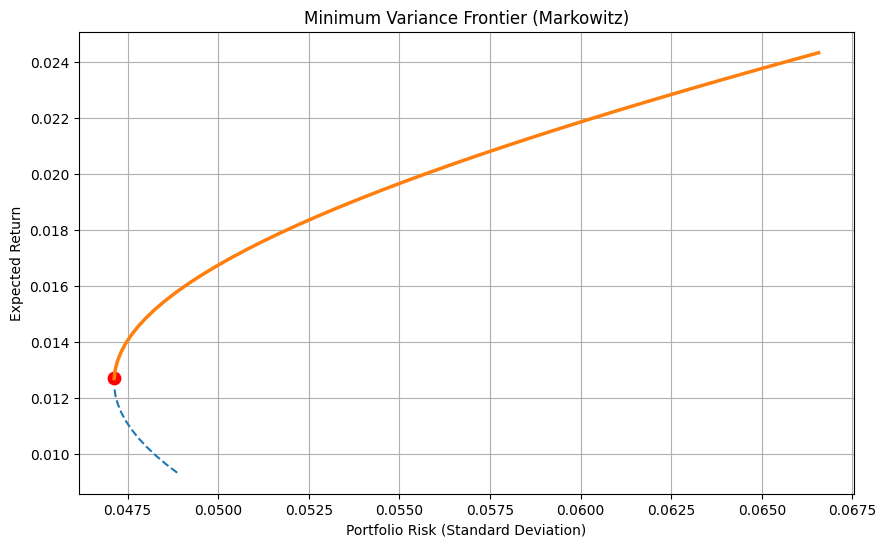

In [ ]:
# Graphic of the frontier

plt.figure(figsize=(10,6))

plt.plot(inefficient_vols, inefficient_returns, '--', label="Inefficient frontier")
plt.plot(efficient_vols, efficient_returns, linewidth=2.5, label="Efficient frontier")

plt.scatter(gmv_volatility, gmv_return, color='red', s=80, label="GMV portfolio")

plt.title("Minimum Variance Frontier (Markowitz)")
plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()

The graph shows the standard convex shape of the Markowitz minimum variance frontier. The upper branch is efficient because it offers the highest expected return for each level of risk, whereas the lower branch is dominated

# Question B.2
Repeat the the same task, modeling the covariance structure according to factor
structure based on the five factors by Fama and French (available on Kenneth
French’s website). Obtain the frontier both assuming uncorrelated and correlated
factors. In the latter case, simply estimate correlations across factors over the sample period

In [ ]:
# Load Fama-French 5 Factor dataset

file_path = "/content/drive/MyDrive/JUL_eco/F-F_Research_Data_5_Factors_2x3.csv"
ff_data = pd.read_csv(file_path, skiprows=3)

print(ff_data.head())

  Unnamed: 0    Mkt-RF       SMB       HML       RMW       CMA        RF
0     196307     -0.39     -0.48     -0.81      0.64     -1.15      0.27
1     196308      5.08     -0.80      1.70      0.40     -0.38      0.25
2     196309     -1.57     -0.43      0.00     -0.78      0.15      0.27
3     196310      2.54     -1.34     -0.04      2.79     -2.25      0.29
4     196311     -0.86     -0.85      1.73     -0.43      2.27      0.27


In [ ]:
# Rename first column
ff_data = ff_data.rename(columns={"Unnamed: 0": "Date"})

# Keep only rows that match YYYYMM
ff_data = ff_data[ff_data["Date"].astype(str).str.match(r"^\d{6}$")]

# Convert date
ff_data["Date"] = pd.to_datetime(ff_data["Date"], format="%Y%m")

# Set index
ff_data = ff_data.set_index("Date")

# Convert percent to decimal
ff_data = ff_data.astype(float) / 100

print(ff_data.head())
print(ff_data.tail())

            Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                      
1963-07-01 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1963-08-01  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
1963-09-01 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
1963-10-01  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
1963-11-01 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027
            Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                      
2025-09-01  0.0339 -0.0218 -0.0105 -0.0206 -0.0222  0.0033
2025-10-01  0.0196 -0.0130 -0.0310 -0.0521 -0.0403  0.0037
2025-11-01 -0.0013  0.0147  0.0376  0.0142  0.0068  0.0030
2025-12-01 -0.0036 -0.0022  0.0242  0.0040  0.0037  0.0034
2026-01-01  0.0102  0.0326  0.0370  0.0183  0.0181  0.0030


In [ ]:
# Separation of risk-free factors and rates
factors = ff_data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]

rf = ff_data["RF"]

In [ ]:
# Align with the returns of the 10 shares
data = Our_return.join(factors).join(rf)

data = data.dropna()

print("Sample used:")
print(data.index.min(), "to", data.index.max())

Sample used:
2016-02-01 00:00:00 to 2026-01-01 00:00:00


In [ ]:
# Estimate the betas (regressions)
import statsmodels.api as sm

betas = []
residual_var = []

for stock in Our_return.columns:

    excess_return = data[stock] - data["RF"]

    X = data[["Mkt-RF","SMB","HML","RMW","CMA"]]
    X = sm.add_constant(X)

    model = sm.OLS(excess_return, X).fit()

    betas.append(model.params[1:])
    residual_var.append(model.resid.var())

betas = np.array(betas)
residual_var = np.array(residual_var)

B = betas

# Covariance of factors
factor_cov = factors.loc[data.index].cov().values

#Uncorrelated factors version
factor_var_diag = np.diag(np.diag(factor_cov))

#Construct factor covariance of actions
cov_factor_corr = B @ factor_cov @ B.T + np.diag(residual_var)

cov_factor_uncorr = B @ factor_var_diag @ B.T + np.diag(residual_var)

# Portfolio functions
def port_return(w, mu):
    return np.dot(w, mu)

def port_var(w, cov):
    return np.dot(w.T, np.dot(cov, w))

def port_vol(w, cov):
    return np.sqrt(port_var(w, cov))

#Function to calculate the efficient frontier
from scipy.optimize import minimize

def efficient_frontier(mean_returns, cov_matrix):

    n_assets = len(mean_returns)

    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 40)

    vols = []
    rets = []

    for target in target_returns:

        constraints = (
            {"type":"eq","fun": lambda w: np.sum(w)-1},
            {"type":"eq","fun": lambda w: port_return(w, mean_returns)-target}
        )

        init = np.ones(n_assets)/n_assets

        res = minimize(port_var, init,
                       args=(cov_matrix,),
                       method="SLSQP",
                       constraints=constraints)

        if res.success:

            w = res.x

            vols.append(port_vol(w, cov_matrix))
            rets.append(port_return(w, mean_returns))

    return np.array(vols), np.array(rets)

# calculation of the two frontiers
vol_uncorr, ret_uncorr = efficient_frontier(mean_returns, cov_factor_uncorr)
vol_corr, ret_corr = efficient_frontier(mean_returns, cov_factor_corr)

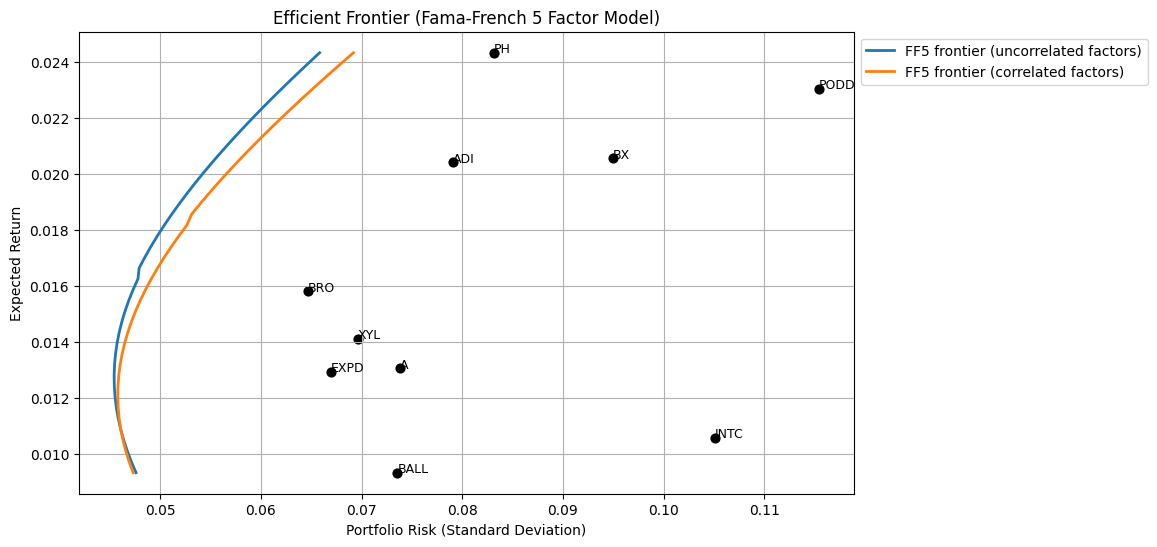

In [ ]:
# graph of the borders
plt.figure(figsize=(10,6))

# Uncorrelated factor frontier
plt.plot(vol_uncorr, ret_uncorr,
         label="FF5 frontier (uncorrelated factors)",
         linewidth=2)

# Correlated factor frontier
plt.plot(vol_corr, ret_corr,
         label="FF5 frontier (correlated factors)",
         linewidth=2)


# Add the 10 actions

stock_returns = Our_return.mean()
stock_vol = Our_return.std()

plt.scatter(stock_vol, stock_returns, color="black", s=40)

# display the tickers
for stock in Our_return.columns:

    x = Our_return[stock].std()
    y = Our_return[stock].mean()

    plt.text(x, y, stock, fontsize=9)


plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")

plt.title("Efficient Frontier (Fama-French 5 Factor Model)")

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.grid(True)

plt.show()

In [ ]:
#correlation factors
factor_corr = factors.corr()

print(factor_corr)

          Mkt-RF       SMB       HML       RMW       CMA
Mkt-RF  1.000000  0.275591 -0.206338 -0.189713 -0.352695
SMB     0.275591  1.000000  0.012739 -0.341617 -0.080876
HML    -0.206338  0.012739  1.000000  0.091257  0.682116
RMW    -0.189713 -0.341617  0.091257  1.000000  0.004625
CMA    -0.352695 -0.080876  0.682116  0.004625  1.000000


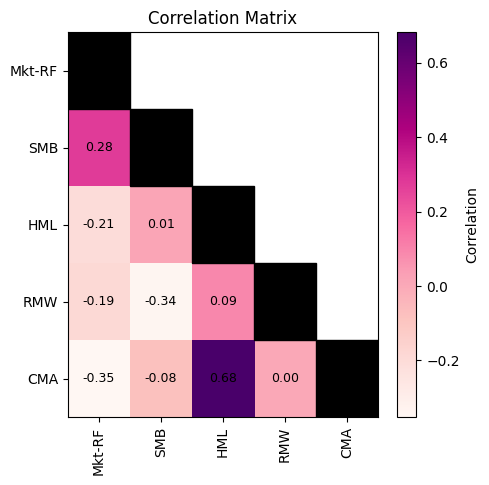

In [ ]:
# Heatmap of the correlation matrix
mask = np.triu(np.ones_like(factor_corr, dtype=bool))
corr_lower = factor_corr.mask(mask)

plt.figure(figsize=(5,5))

# Heatmap
plt.imshow(corr_lower, cmap="RdPu", aspect="auto")

plt.colorbar(label="Correlation")

# Diagonal in black
for i in range(len(factor_corr)):
    plt.gca().add_patch(
        plt.Rectangle((i-0.5, i-0.5), 1, 1, color="black")
    )

# Add the values in the boxes
for i in range(len(factor_corr)):
    for j in range(len(factor_corr)):
        if not mask[i, j]:
            value = factor_corr.iloc[i, j]
            plt.text(j, i, f"{value:.2f}",
                     ha="center", va="center",
                     color="black", fontsize=9)

plt.xticks(range(len(factor_corr.columns)), factor_corr.columns, rotation=90)
plt.yticks(range(len(factor_corr.index)), factor_corr.index)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows how the five Fama-French factors are related to each other. Most correlations are relatively low, which means that the factors capture different sources of risk in the market. However, we can still observe some stronger relationships. For example, HML and CMA have a relatively high positive correlation (around 0.68). Overall, the factors are not completely independent, but they still provide different information about stock returns.

# Question B.3

Determine the mean and standard deviation of returns of:
(i) the equally weighted portfolio of the 10 randomly selected stocks (EW10);
(ii) the equally weighted portfolio containing 100 randomly selected stocks from
the initial dataset (EW100);
(iii) the S&P 500 index

In [ ]:
# Equally weighted portfolio based on our 10 selected stocks

my_ew10_path = Our_return.mean(axis=1)

my_ew10_avg = my_ew10_path.mean()
my_ew10_risk = my_ew10_path.std()

print("EW10 portfolio")
print("Average monthly return :", my_ew10_avg)
print("Monthly standard deviation :", my_ew10_risk)

EW10 portfolio
Average monthly return : 0.0164164201880147
Monthly standard deviation : 0.0538475179083786


The EW10 portfolio is constructed by assigning the same weight to each of our 10 selected stocks. Its monthly return is therefore the simple average of the individual returns in our sample.

In [ ]:
# Equally weighted portfolio based on 100 randomly selected stocks

np.random.seed(123)

my_big_choice = np.random.choice(tickers, size=100, replace=False)

my_big_price_cols = [stock + "_Adj Close" for stock in my_big_choice]

Choice_100 = df[my_big_price_cols].copy()
Choice_100.columns = my_big_choice

big_return_block = Choice_100.pct_change().dropna()

my_ew100_path = big_return_block.mean(axis=1)

my_ew100_avg = my_ew100_path.mean()
my_ew100_risk = my_ew100_path.std()

print("\nEW100 portfolio")
print("Average monthly return :", my_ew100_avg)
print("Monthly standard deviation :", my_ew100_risk)


EW100 portfolio
Average monthly return : 0.015383734866518709
Monthly standard deviation : 0.04923015465197661


The EW100 portfolio is built in the same way, but with a much larger number of stocks. This allows us to examine how broader diversification affects portfolio return and risk.

In [ ]:
# Import S&P 500 index for comparison

market_proxy = yf.download("^GSPC", start="2016-01-01", end="2026-02-01", interval="1mo")

sp500_price_track = market_proxy["Close"]

sp500_return_track = sp500_price_track.pct_change().dropna()

my_sp500_avg = float(sp500_return_track.mean().iloc[0])
my_sp500_risk = float(sp500_return_track.std().iloc[0])

print("S&P 500 index")
print("Average monthly return :", my_sp500_avg)
print("Monthly standard deviation :", my_sp500_risk)

/tmp/ipykernel_3230/2017534406.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_proxy = yf.download("^GSPC", start="2016-01-01", end="2026-02-01", interval="1mo")
[*********************100%***********************]  1 of 1 completed

S&P 500 index
Average monthly return : 0.011607929133386567
Monthly standard deviation : 0.04322080984016574


The dataset contains the individual stocks that compose the S&P 500 but not the index itself. Therefore, the S&P 500 index is downloaded separately and used as a market benchmark. The index represents the overall performance of the U.S. equity market and allows us to compare the performance of our equally weighted portfolios with the market portfolio.

In [ ]:
# Summary table for Part B.3

b3_summary = pd.DataFrame({
    "Mean monthly return": [my_ew10_avg, my_ew100_avg, my_sp500_avg],
    "Monthly standard deviation": [my_ew10_risk, my_ew100_risk, my_sp500_risk]
}, index=["EW10", "EW100", "S&P 500"])

print("\nSummary of Part B.3:")
print(b3_summary)


Summary of Part B.3:
         Mean monthly return  Monthly standard deviation
EW10                0.016416                    0.053848
EW100               0.015384                    0.049230
S&P 500             0.011608                    0.043221


The results show that EW10 has the highest average monthly return, but also the highest volatility. EW100 offers a slightly lower average return, together with a lower level of risk, which suggests that broader diversification improves the risk-return trade-off. The S&P 500 index has the lowest volatility among the three portfolios and serves as a useful market benchmark for the comparison with the efficient frontiers in the next part.

# Question B.4
Compare the three efficient frontiers obtained, also against the portfolios from point
B.3), and discuss your results

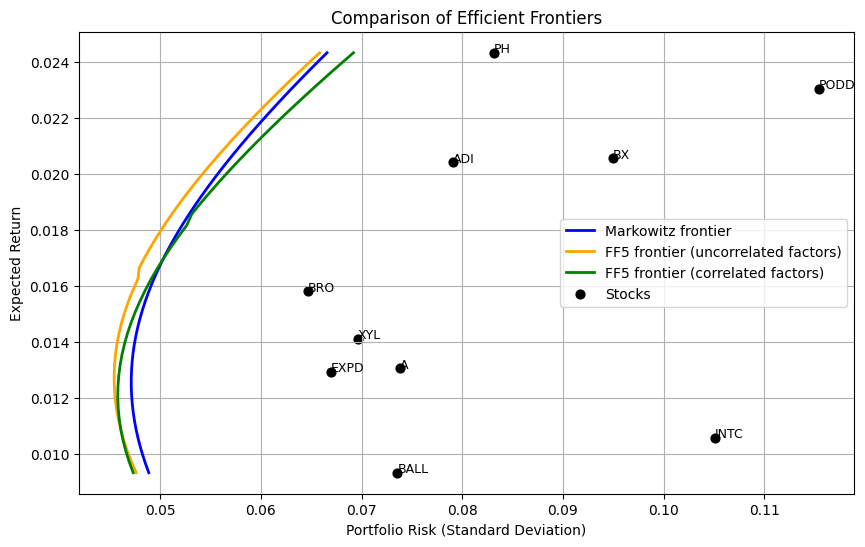

In [ ]:
#graph of the 3 borders
stock_returns = Our_return.mean()
stock_volatility = Our_return.std()

plt.figure(figsize=(10,6))

# Markowitz frontier
plt.plot(frontier_volatility, frontier_returns,
         color="blue", linewidth=2, label="Markowitz frontier")

# FF5 frontier - uncorrelated factors
plt.plot(vol_uncorr, ret_uncorr,
         color="orange", linewidth=2, label="FF5 frontier (uncorrelated factors)")

# FF5 frontier - correlated factors
plt.plot(vol_corr, ret_corr,
         color="green", linewidth=2, label="FF5 frontier (correlated factors)")

# Individual stocks
plt.scatter(stock_volatility, stock_returns, color="black", s=40, label="Stocks")

for stock in Our_return.columns:
    plt.text(stock_volatility[stock],
             stock_returns[stock],
             stock,
             fontsize=9)

plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.title("Comparison of Efficient Frontiers")

plt.legend(loc="best")

plt.grid(True)
plt.show()

The figure compares three efficient frontiers: the traditional Markowitz frontier and the frontiers obtained using the Fama-French 5-factor model under two assumptions, with uncorrelated and correlated factors.
From the graph, we can see that the frontier obtained with uncorrelated factors is generally a little above the others. This means that, for a similar level of risk, portfolios based on uncorrelated factors tend to offer higher expected returns.

This can be explained by diversification. When the factors are uncorrelated, they represent independent sources of risk, which improves diversification within the portfolio. However, if the factors are correlated, part of the information they contain overlaps, which reduces the diversification benefits.

Overall, the frontier obtained with uncorrelated factors appears a little more attractive in terms of the risk-return trade-off. The Markowitz frontier remains close to the two factor-based frontiers, but the factor model provides an alternative way to estimate expected returns by incorporating common sources of systematic risk.

# Question B5
Pick 5 stocks from the 10 randomly selected ones, so that to determine the “best” efficient frontier following the Markowitz approach as in point B.1). Describe the
rules you follow to choose the stocks. Discuss how the frontier obtained in this way
differs from the one at point B.1)

In [ ]:
#we take some statistics for the selection
stock_mean = Our_return.mean()
stock_vol = Our_return.std()
avg_corr = corr_matrix.mean()

selection_table = pd.DataFrame({
    "Mean return": stock_mean,
    "Volatility": stock_vol,
    "Average correlation": avg_corr
})

# Standardization of variables to combine them into a single score
selection_table["z_mean"] = (selection_table["Mean return"] - selection_table["Mean return"].mean()) / selection_table["Mean return"].std()
selection_table["z_vol"] = (selection_table["Volatility"] - selection_table["Volatility"].mean()) / selection_table["Volatility"].std()
selection_table["z_corr"] = (selection_table["Average correlation"] - selection_table["Average correlation"].mean()) / selection_table["Average correlation"].std()

# We build a ranking score
selection_table["Selection score"] = (
    selection_table["z_mean"]
    - selection_table["z_vol"]
    - selection_table["z_corr"]
)

selection_table = selection_table.sort_values(by="Selection score", ascending=False)

print("Ranking of the 10 stocks ")
print(selection_table[["Mean return", "Volatility", "Average correlation", "Selection score"]])

# We select the top 5 stocks
best_5_stocks = selection_table.head(5).index.tolist()

print("\nSelected top 5 stocks ")
print(best_5_stocks)

Ranking of the 10 stocks 
      Mean return  Volatility  Average correlation  Selection score
BRO      0.015803    0.064653             0.345899         2.147749
PODD     0.023036    0.115402             0.341664         0.610672
ADI      0.020409    0.079045             0.469975         0.450306
PH       0.024313    0.083139             0.523967         0.197070
EXPD     0.012940    0.066987             0.459630        -0.112595
BALL     0.009342    0.073567             0.391810        -0.232120
BX       0.020555    0.094956             0.462824        -0.351220
XYL      0.014116    0.069605             0.493087        -0.509257
INTC     0.010592    0.105089             0.338632        -1.095650
A        0.013058    0.073771             0.504059        -1.104956

Selected top 5 stocks 
['BRO', 'PODD', 'ADI', 'PH', 'EXPD']


To select the five stocks, we adopt a diversification-based approach consistent with the Markowitz approach. We consider three elements: the average return of each stock, its level of volatility, and its correlation with the other assets. The goal is to select stocks that offer relatively good returns while not being excessively risky or too strongly correlated with the rest of the portfolio, to preserve the benefits of diversification. By selecting assets with different return dynamics, we want to reduce the overall portfolio variance for a given level of expected return. The five stocks selected are BRO, PODD, ADI, PH, and EXPD.

In [ ]:
# Creation of a subsample with only the top 5 stocks
Best5_return = Our_return[best_5_stocks].copy()

best5_mean_returns = Best5_return.mean()
best5_cov_matrix = Best5_return.cov()
best5_corr_matrix = Best5_return.corr()

print("\nMean returns top 5 stocks :")
print(best5_mean_returns)

print("\nCovariance matrix top 5 stocks:")
print(best5_cov_matrix)

print("\nCorrelation matrix top 5 stocks:")
print(best5_corr_matrix)


Mean returns top 5 stocks :
BRO     0.015803
PODD    0.023036
ADI     0.020409
PH      0.024313
EXPD    0.012940
dtype: float64

Covariance matrix top 5 stocks:
           BRO      PODD       ADI        PH      EXPD
BRO   0.004180  0.001317  0.001308  0.001802  0.001381
PODD  0.001317  0.013318  0.002248  0.002544  0.001833
ADI   0.001308  0.002248  0.006248  0.004160  0.002723
PH    0.001802  0.002544  0.004160  0.006912  0.002890
EXPD  0.001381  0.001833  0.002723  0.002890  0.004487

Correlation matrix top 5 stocks:
           BRO      PODD       ADI        PH      EXPD
BRO   1.000000  0.176526  0.255857  0.335224  0.318942
PODD  0.176526  1.000000  0.246460  0.265111  0.237054
ADI   0.255857  0.246460  1.000000  0.633008  0.514221
PH    0.335224  0.265111  0.633008  1.000000  0.519011
EXPD  0.318942  0.237054  0.514221  0.519011  1.000000


In [ ]:
#we know create the Markowitz efficient frontier with the 5 selected stocks
def best5_efficient_portfolio(target_return, mean_returns, cov_matrix):

    n_assets = len(mean_returns)

    constraints = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: np.dot(w, mean_returns) - target_return}
    )

    init = np.ones(n_assets) / n_assets

    res = minimize(
        port_var,
        init,
        args=(cov_matrix,),
        method="SLSQP",
        constraints=constraints
    )

    return res.x



In [ ]:
#we continue to calculate the frontier
target_returns_best5 = np.linspace(best5_mean_returns.min(), best5_mean_returns.max(), 50)

frontier_volatility_best5 = []
frontier_returns_best5 = []

for target in target_returns_best5:

    w = best5_efficient_portfolio(target, best5_mean_returns, best5_cov_matrix)

    frontier_returns_best5.append(np.dot(w, best5_mean_returns))
    frontier_volatility_best5.append(np.sqrt(port_var(w, best5_cov_matrix)))

frontier_returns_best5 = np.array(frontier_returns_best5)
frontier_volatility_best5 = np.array(frontier_volatility_best5)

In [ ]:
#we calculate the gLobal minimum vairance portfolio
gmv_index_best5 = np.argmin(frontier_volatility_best5)

gmv_return_best5 = frontier_returns_best5[gmv_index_best5]
gmv_volatility_best5 = frontier_volatility_best5[gmv_index_best5]

gmv_weights_best5 = best5_efficient_portfolio(
    frontier_returns_best5[gmv_index_best5],
    best5_mean_returns,
    best5_cov_matrix
)

gmv_weights_best5_df = pd.Series(gmv_weights_best5, index=best_5_stocks)

print("GMV portfolio for the selected stocks")
print("Return:", gmv_return_best5)
print("Volatility:", gmv_volatility_best5)

print("\nGMV weights:")
print(gmv_weights_best5_df)

GMV portfolio for the selected stocks
Return: 0.016421885084420718
Volatility: 0.05115477105855889

GMV weights:
BRO     0.421986
PODD    0.101268
ADI     0.133155
PH      0.022566
EXPD    0.321026
dtype: float64


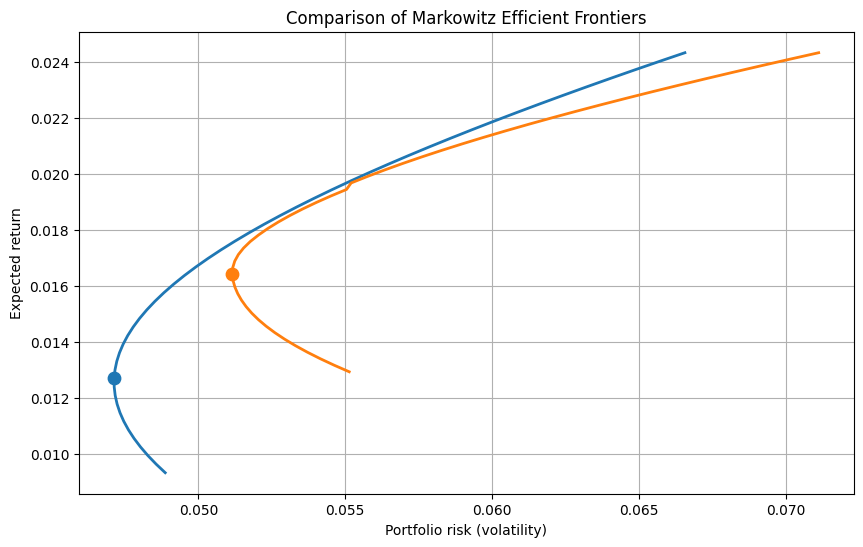

In [ ]:
#graphic comparison between the two frontier
plt.figure(figsize=(10,6))

# Frontier from B.1 (10 stocks)
plt.plot(frontier_volatility, frontier_returns,
         label="Frontier (10 stocks)",
         linewidth=2)

# Frontier from B.5 (5 selected stocks)
plt.plot(frontier_volatility_best5, frontier_returns_best5,
         label="Frontier (5 selected stocks)",
         linewidth=2)

# GMV points
plt.scatter(gmv_volatility, gmv_return,
            label="GMV (10 stocks)",
            s=80)

plt.scatter(gmv_volatility_best5, gmv_return_best5,
            label="GMV (5 stocks)",
            s=80)

plt.xlabel("Portfolio risk (volatility)")
plt.ylabel("Expected return")
plt.title("Comparison of Markowitz Efficient Frontiers")
plt.grid(True)

plt.show()

When we compare the two frontiers, we can see that the frontier obtained with the 10 stocks tends to dominate the one based on only 5 stocks, particularly for portfolios with lower levels of risk. This result follows portfolio theory, because including more assets generally increases diversification possibilities and increases the range of possible portfolios.
Nevertheless, the frontier constructed with the 5 selected stocks remains quite close to the original one for certain levels of risk and return. This suggests that the selected subset still captures an important part of the risk-return opportunities provided by the initial group of 10 stocks. Using fewer assets may make the portfolio easier to construct, but it can also limit diversification compared to using the full set of assets.

## Question B.6
Repeat point B.1) adding to the available assets both
(i) a market index for developed markets;
(ii) a market index for emerging markets.
Both indexes are available on Kenneth French’s website. How does international
diversification impact the efficient set of portfolios?


In [ ]:
file1_path = "/content/drive/MyDrive/JUL_eco/Emerging_5_Factors.csv"
em_world = pd.read_csv(file1_path, skiprows=6)
file2_path = "/content/drive/MyDrive/JUL_eco/Developed_3_Factors.csv"
dev_world = pd.read_csv(file2_path, skiprows=6)

# rename the first column as Date
dev_world.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
em_world.rename(columns={"Unnamed: 0": "Date"}, inplace=True)

# convert Date to numeric
dev_world["Date"] = pd.to_numeric(dev_world["Date"], errors="coerce")
em_world["Date"] = pd.to_numeric(em_world["Date"], errors="coerce")

# keep only monthly observations (YYYYMM)
dev_world = dev_world[(dev_world["Date"] >= 100000) & (dev_world["Date"] <= 999999)]
em_world = em_world[(em_world["Date"] >= 100000) & (em_world["Date"] <= 999999)]

print(dev_world.head())
print(em_world.head())



       Date      Mkt-RF        SMB        HML    RF
0  199007.0    0.77        0.53     -0.36      0.68
1  199008.0   -10.77     -1.51       0.48      0.66
2  199009.0  -11.89       1.32       0.80      0.60
3  199010.0     9.35      -7.58     -4.48      0.68
4  199011.0   -3.72       1.43       1.13      0.57
       Date     Mkt-RF       SMB      HML       RMW         CMA    RF
0  198907.0    0.60     -0.39     15.53    -99.99    -99.99      0.70
1  198908.0   1.63       8.78     -3.73    -99.99    -99.99      0.74
2  198909.0  14.41       3.32     -7.70    -99.99    -99.99      0.65
3  198910.0   -2.18     -0.49     -4.36    -99.99    -99.99      0.68
4  198911.0   0.72      0.43       2.22    -99.99    -99.99      0.69


In [ ]:
dev_world["Date"] = pd.to_datetime(dev_world["Date"].astype(int).astype(str), format="%Y%m")
em_world["Date"] = pd.to_datetime(em_world["Date"].astype(int).astype(str), format="%Y%m")

dev_world.set_index("Date", inplace=True)
em_world.set_index("Date", inplace=True)

In [ ]:
# convert useful columns to numeric
dev_world["Mkt-RF"] = pd.to_numeric(dev_world["Mkt-RF"], errors="coerce")
dev_world["RF"] = pd.to_numeric(dev_world["RF"], errors="coerce")

em_world["Mkt-RF"] = pd.to_numeric(em_world["Mkt-RF"], errors="coerce")
em_world["RF"] = pd.to_numeric(em_world["RF"], errors="coerce")

In [ ]:
# build developed and emerging market returns

dev_market_path = (dev_world["Mkt-RF"] + dev_world["RF"]) / 100
em_market_path = (em_world["Mkt-RF"] + em_world["RF"]) / 100

dev_market_path.name = "Developed"
em_market_path.name = "Emerging"

print("Developed market return preview:")
print(dev_market_path.head())

print("\nEmerging market return preview:")
print(em_market_path.head())

Developed market return preview:
Date
1990-07-01    0.0145
1990-08-01   -0.1011
1990-09-01   -0.1129
1990-10-01    0.1003
1990-11-01   -0.0315
Name: Developed, dtype: float64

Emerging market return preview:
Date
1989-07-01    0.0130
1989-08-01    0.0237
1989-09-01    0.1506
1989-10-01   -0.0150
1989-11-01    0.0141
Name: Emerging, dtype: float64


We reconstruct the monthly returns of the developed and emerging market indices by adding the risk-free rate to the excess market return reported in the Kenneth French files. The resulting series are then expressed in decimal form.

In [ ]:
global_mix_box = pd.concat([Our_return, dev_market_path, em_market_path], axis=1)

global_mix_box = global_mix_box.dropna()

print(global_mix_box.head())
print(global_mix_box.tail())
print(global_mix_box.shape)

                BALL        BX       ADI       XYL       BRO        PH  \
Date                                                                     
2016-02-01 -0.008978 -0.011420 -0.016153  0.040612  0.068099  0.041581   
2016-03-01  0.078498  0.105570  0.126195  0.097885  0.112540  0.104483   
2016-04-01  0.001262 -0.021746 -0.048488  0.021516 -0.019274  0.044472   
2016-05-01  0.012889 -0.036197  0.038708  0.068933  0.027058 -0.010171   
2016-06-01  0.001675 -0.063001 -0.024760  0.003351  0.042746 -0.053801   

                PODD         A      EXPD      INTC  Developed  Emerging  
Date                                                                     
2016-02-01 -0.076552 -0.007968  0.014628 -0.046099    -0.0048   -0.0059  
2016-03-01  0.082245  0.066934  0.066186  0.102897     0.0694    0.1208  
2016-04-01  0.004222  0.026851  0.016390 -0.063987     0.0192    0.0126  
2016-05-01 -0.098498  0.124702 -0.021367  0.043263     0.0046   -0.0350  
2016-06-01  0.007328 -0.033340  0.018

The return series are merged using their common monthly dates. We then remove missing observations so that all assets are aligned over the same sample period before recomputing the efficient frontier.

In [ ]:
#  Markowitz inputs with 12 assets
world_mean_vector = global_mix_box.mean().values
world_cov_matrix = global_mix_box.cov().values
world_asset_count = len(world_mean_vector)

print("Number of assets :", world_asset_count)

# Portfolio functions for the international case
def global_return_recipe(weights):
    return np.dot(weights, world_mean_vector)

def global_risk_recipe(weights):
    return np.sqrt(np.dot(weights.T, np.dot(world_cov_matrix, weights)))

def global_variance_recipe(weights):
    return np.dot(weights.T, np.dot(world_cov_matrix, weights))

# Minimum variance portfolio for a target return
def global_efficient_pack(target_return):

    world_rules = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: global_return_recipe(w) - target_return}
    )

    world_start = np.ones(world_asset_count) / world_asset_count

    world_result = minimize(
        global_variance_recipe,
        world_start,
        method='SLSQP',
        constraints=world_rules
    )

    return world_result.x


Number of assets : 12


In [ ]:
# Build the new frontier
global_target_grid = np.linspace(world_mean_vector.min(), world_mean_vector.max(), 50)

global_frontier_return = []
global_frontier_risk = []
global_frontier_weights = []

for target in global_target_grid:
    pack = global_efficient_pack(target)

    global_frontier_return.append(global_return_recipe(pack))
    global_frontier_risk.append(global_risk_recipe(pack))
    global_frontier_weights.append(pack)

global_frontier_return = np.array(global_frontier_return)
global_frontier_risk = np.array(global_frontier_risk)
global_frontier_weights = np.array(global_frontier_weights)

# Global minimum variance portfolio
global_gmv_spot = np.argmin(global_frontier_risk)

global_gmv_return = global_frontier_return[global_gmv_spot]
global_gmv_risk = global_frontier_risk[global_gmv_spot]
global_gmv_weights = global_frontier_weights[global_gmv_spot]

print("\nInternational GMV portfolio")
print("Average monthly return :", global_gmv_return)
print("Monthly standard deviation :", global_gmv_risk)

print("\nInternational GMV weights:")
print(pd.Series(global_gmv_weights, index=global_mix_box.columns))


International GMV portfolio
Average monthly return : 0.007916648420013815
Monthly standard deviation : 0.0364216676081441

International GMV weights:
BALL         0.096028
BX          -0.091795
ADI          0.001768
XYL          0.001085
BRO          0.247947
PH          -0.192262
PODD        -0.008540
A           -0.016293
EXPD         0.130862
INTC        -0.017320
Developed    0.401021
Emerging     0.447500
dtype: float64


The global minimum variance portfolio also changes significantly. A large fraction of the optimal allocation is invested in the developed and emerging market indices. This shows that international assets provide strong diversification benefits relative to a portfolio composed only of U.S. stocks.

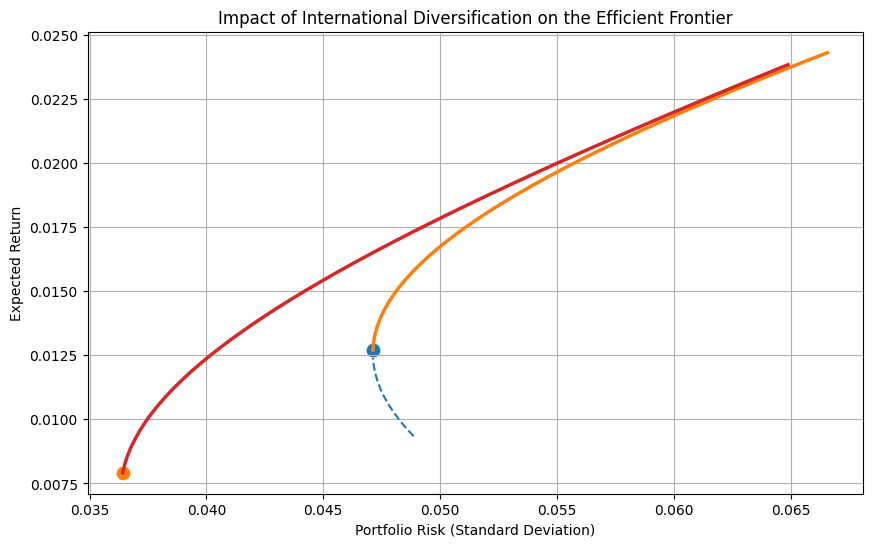

In [ ]:
# Efficient and inefficient branches
global_good_return = global_frontier_return[global_gmv_spot:]
global_good_risk = global_frontier_risk[global_gmv_spot:]

global_bad_return = global_frontier_return[:global_gmv_spot]
global_bad_risk = global_frontier_risk[:global_gmv_spot]

# Compare original B.1 frontier with the international one
plt.figure(figsize=(10, 6))

# Original frontier from B.1
plt.plot(inefficient_vols, inefficient_returns, '--', label="Original inefficient frontier")
plt.plot(efficient_vols, efficient_returns, linewidth=2.5, label="Original efficient frontier")

# New frontier with developed + emerging markets
plt.plot(global_bad_risk, global_bad_return, '--', label="International inefficient frontier")
plt.plot(global_good_risk, global_good_return, linewidth=2.5, label="International efficient frontier")

# GMV points
plt.scatter(gmv_volatility, gmv_return, s=80, label="Original GMV")
plt.scatter(global_gmv_risk, global_gmv_return, s=80, label="International GMV")

plt.title("Impact of International Diversification on the Efficient Frontier")
plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.grid(True)



After adding the developed and emerging market indices to the investment universe, the efficient frontier shifts to the left. This indicates that international diversification improves the risk-return trade-off. Investors can achieve the same expected return with lower portfolio risk.

In [ ]:
# Before and after diversification summary

b6_compare_table = pd.DataFrame({
    "Average monthly return": [gmv_return, global_gmv_return],
    "Monthly standard deviation": [gmv_volatility, global_gmv_risk]
}, index=["Original GMV", "International GMV"])

print(b6_compare_table)

                   Average monthly return  Monthly standard deviation
Original GMV                     0.012703                    0.047128
International GMV                0.007917                    0.036422


The comparison shows that adding developed and emerging market indices reduces the risk of the global minimum variance portfolio. This confirms that international diversification improves the investment opportunity set.

# Question B.7
Repeat point B.1) imposing the short selling constraint and comment

In [ ]:
#Markowitz frontier without short selling

mean_returns = Our_return.mean().values
cov_matrix = Our_return.cov().values
n_assets = len(mean_returns)

# Portfolio functions
def portfolio_return_noshort(weights):
    return np.dot(weights, mean_returns)

def portfolio_variance_noshort(weights):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

def portfolio_volatility_noshort(weights):
    return np.sqrt(portfolio_variance_noshort(weights))

# Minimum variance portfolio for a given target return
def efficient_portfolio_noshort(target_return):

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return_noshort(w) - target_return}
    )

    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_weights = np.ones(n_assets) / n_assets

    result = minimize(
        portfolio_variance_noshort,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return result

# Build the constrained frontier
target_returns_noshort = np.linspace(mean_returns.min(), mean_returns.max(), 50)

frontier_returns_noshort = []
frontier_volatility_noshort = []

for target in target_returns_noshort:

    result = efficient_portfolio_noshort(target)

    if result.success:
        weights = result.x
        frontier_returns_noshort.append(portfolio_return_noshort(weights))
        frontier_volatility_noshort.append(portfolio_volatility_noshort(weights))

frontier_returns_noshort = np.array(frontier_returns_noshort)
frontier_volatility_noshort = np.array(frontier_volatility_noshort)

# GMV portfolio without short selling
gmv_index_noshort = np.argmin(frontier_volatility_noshort)

gmv_return_noshort = frontier_returns_noshort[gmv_index_noshort]
gmv_volatility_noshort = frontier_volatility_noshort[gmv_index_noshort]

gmv_weights_noshort_result = efficient_portfolio_noshort(gmv_return_noshort)
gmv_weights_noshort = gmv_weights_noshort_result.x

gmv_weights_noshort_df = pd.Series(gmv_weights_noshort, index=Our_return.columns)

print("Global Minimum Variance Portfolio without short selling")
print("Return:", gmv_return_noshort)
print("Volatility:", gmv_volatility_noshort)

print("\nGMV Portfolio Weights without short selling:")
print(gmv_weights_noshort_df)

Global Minimum Variance Portfolio without short selling
Return: 0.01423067792748226
Volatility: 0.047830202190702276

GMV Portfolio Weights without short selling:
BALL    0.172718
BX      0.000000
ADI     0.079619
XYL     0.108206
BRO     0.322360
PH      0.007000
PODD    0.027553
A       0.058631
EXPD    0.182389
INTC    0.041524
dtype: float64


The Global Minimum Variance portfolio without short selling has an expected monthly return of around 1.42% and a volatility of about 4.78%. Because short selling is not allowed, all the portfolio weights are positive and the investment is spread across several assets.

We can see that the largest weight is allocated to BRO, which suggests that this stock plays an important role in reducing the overall portfolio risk. Other stocks such as EXPD, BALL, and XYL also have relatively significant weights in the portfolio. On the other hand, some assets like BX have a weight of zero, meaning that they are not included in the portfolio under this constraint.

Overall, the portfolio remains diversified, but restricting short selling reduces the flexibility of the optimization. This explains why the composition of the portfolio is different from the GMV portfolio obtained in B.1.

In [ ]:
# Efficient and inefficient parts of the constrained frontier
efficient_returns_noshort = frontier_returns_noshort[gmv_index_noshort:]
efficient_vols_noshort = frontier_volatility_noshort[gmv_index_noshort:]

inefficient_returns_noshort = frontier_returns_noshort[:gmv_index_noshort]
inefficient_vols_noshort = frontier_volatility_noshort[:gmv_index_noshort]

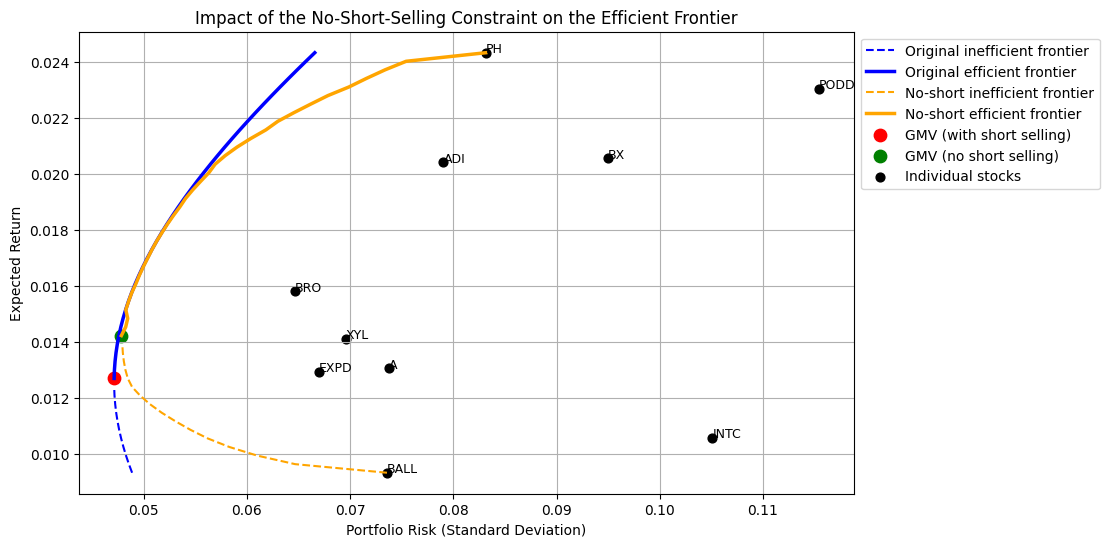

In [ ]:
# Individual stock statistics
stock_returns = Our_return.mean()
stock_volatility = Our_return.std()

plt.figure(figsize=(10,6))

# Original frontier
plt.plot(inefficient_vols, inefficient_returns, '--',
         color="blue", label="Original inefficient frontier")
plt.plot(efficient_vols, efficient_returns,
         color="blue", linewidth=2.5, label="Original efficient frontier")

# No-short-selling frontier
plt.plot(inefficient_vols_noshort, inefficient_returns_noshort, '--',
         color="orange", label="No-short inefficient frontier")
plt.plot(efficient_vols_noshort, efficient_returns_noshort,
         color="orange", linewidth=2.5, label="No-short efficient frontier")

# GMV portfolios
plt.scatter(gmv_volatility, gmv_return,
            color="red", s=80, label="GMV (with short selling)")
plt.scatter(gmv_volatility_noshort, gmv_return_noshort,
            color="green", s=80, label="GMV (no short selling)")

# Individual stocks
plt.scatter(stock_volatility, stock_returns,
            color="black", s=40, label="Individual stocks")

for stock in Our_return.columns:
    plt.text(stock_volatility[stock],
             stock_returns[stock],
             stock,
             fontsize=9)

plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.title("Impact of the No-Short-Selling Constraint on the Efficient Frontier")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.grid(True)
plt.show()

The figure compares the original efficient frontier from B.1 with the frontier obtained when short selling is not allowed. We can observe that the no-short-selling frontier (orange line) generally lies to the right of the original frontier (blue line). This means that for a given level of expected return, the portfolio risk tends to be higher when short selling is restricted.

This result is consistent with portfolio theory. Allowing short selling increases the set of possible portfolios and provides more flexibility to combine assets. When this constraint is imposed, the investor loses the possibility to reduce some risks through negative positions., which reduces diversification opportunities.

The difference can also be seen in the GMV portfolios. The GMV portfolio without short selling (green point) has a slightly higher return but also a different risk level compared with the GMV obtained with short selling (red point). This shows that imposing the constraint changes the optimal portfolio composition and the shape of the efficient frontier.

In [ ]:
# Summary table
b7_compare_table = pd.DataFrame({
    "Average monthly return": [gmv_return, gmv_return_noshort],
    "Monthly standard deviation": [gmv_volatility, gmv_volatility_noshort]
}, index=["Original GMV", "No-short-selling GMV"])

print(b7_compare_table)

                      Average monthly return  Monthly standard deviation
Original GMV                        0.012703                    0.047128
No-short-selling GMV                0.014231                    0.047830


The summary table compares the Global Minimum Variance portfolios obtained with and without the short-selling constraint. We observe that the expected monthly return a little increases when short selling is not allowed, while the volatility also becomes a little higher. This result is consistent with the idea that imposing constraints restricts the set of feasible portfolios and may lead to a less efficient risk-return balance.

In [ ]:
# Comparison of GMV weights
b7_weights_compare = pd.DataFrame({
    "Original GMV": gmv_weights_df,
    "No-short-selling GMV": gmv_weights_noshort_df
})

print(b7_weights_compare)

      Original GMV  No-short-selling GMV
BALL      0.203754              0.172718
BX       -0.048438              0.000000
ADI       0.083575              0.079619
XYL       0.125423              0.108206
BRO       0.332128              0.322360
PH       -0.088244              0.007000
PODD      0.027432              0.027553
A         0.086020              0.058631
EXPD      0.218233              0.182389
INTC      0.060117              0.041524


The table also shows how the portfolio weights change when short selling is excluded. In the original GMV portfolio, some assets have negative weights, meaning that short positions are used to reduce portfolio risk. When the no-short-selling constraint is imposed, these negative weights disappear and some assets receive a weight of zero, such as BX. This indicates that these assets do not help minimize portfolio risk under the constraint. As a result, the portfolio composition becomes a little more concentrated.

## Question C.1
For the case at point B.1), find the global minimum variance (GMV) portfolio.
Then, determine the efficient frontier with the risk-free asset and the tangency
portfolio. For both the GMV and the tangency portfolios, report their
(i) weights,
(ii) mean return,
(iii) standard deviation of returns

In [ ]:
# align the two datasets on common dates
common_dates = Our_return.index.intersection(rf.index)

rf_c1 = rf.loc[common_dates]
Our_return_c1 = Our_return.loc[common_dates]

# average RF
safe_month_avg = rf_c1.mean()

print(Our_return_c1.shape)
print(rf_c1.shape)
print("Average monthly risk-free rate used in C.1:", safe_month_avg)

(120, 10)
(120,)
Average monthly risk-free rate used in C.1: 0.0017658333333333334


We use the monthly risk-free rate reported in the Kenneth French dataset and align it with the sample period of our 10 selected stocks. This ensures that all series are perfectly comparable over time. The average monthly risk-free rate is then used to compute the tangency portfolio.

In [ ]:
# risky asset inputs
c1_mean_track = Our_return.mean().values
c1_cov_track = Our_return.cov().values
c1_asset_total = len(c1_mean_track)

In [ ]:
# portfolio functions

def c1_gain_mix(weights):
    return np.dot(weights, c1_mean_track)

def c1_risk_mix(weights):
    return np.sqrt(np.dot(weights.T, np.dot(c1_cov_track, weights)))

def c1_var_mix(weights):
    return np.dot(weights.T, np.dot(c1_cov_track, weights))

def c1_sharpe_mix(weights):
    pocket_return = c1_gain_mix(weights)
    pocket_risk = c1_risk_mix(weights)
    return (pocket_return - safe_month_avg) / pocket_risk

The tangency portfolio is the risky portfolio that maximizes the Sharpe ratio. the excess return per unit of risk.

In [ ]:
# tangency portfolio
def c1_tangent_pack():

    c1_rules = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )

    c1_start = np.ones(c1_asset_total) / c1_asset_total

    c1_answer = minimize(
        lambda w: -c1_sharpe_mix(w),
        c1_start,
        method='SLSQP',
        constraints=c1_rules
    )

    return c1_answer.x

c1_tangent_weights = c1_tangent_pack()
c1_tangent_return = c1_gain_mix(c1_tangent_weights)
c1_tangent_risk = c1_risk_mix(c1_tangent_weights)
c1_tangent_sharpe = c1_sharpe_mix(c1_tangent_weights)

print("Tangency portfolio")
print("Average monthly return :", c1_tangent_return)
print("Monthly standard deviation :", c1_tangent_risk)
print("Sharpe ratio :", c1_tangent_sharpe)

print("\nTangency portfolio weights:")
print(pd.Series(c1_tangent_weights, index=Our_return.columns))

Tangency portfolio
Average monthly return : 0.025444741521469364
Monthly standard deviation : 0.06977677471265208
Sharpe ratio : 0.33935228857522015

Tangency portfolio weights:
BALL   -0.221410
BX      0.069240
ADI     0.272694
XYL    -0.003429
BRO     0.454615
PH      0.482982
PODD    0.223468
A      -0.165857
EXPD   -0.062476
INTC   -0.049826
dtype: float64


We use the monthly risk-free rate reported in the Kenneth French dataset and align it with the sample period of our 10 selected stocks. This ensures that all series are perfectly comparable over time. The average monthly risk-free rate is then used to compute the tangency portfolio.

In [ ]:
print("GMV portfolio")
print("Average monthly return :", gmv_return)
print("Monthly standard deviation :", gmv_volatility)

print("\nGMV portfolio weights:")
print(pd.Series(gmv_weights, index=Our_return.columns))

GMV portfolio
Average monthly return : 0.012703036451432477
Monthly standard deviation : 0.04712751649691953

GMV portfolio weights:
BALL    0.203754
BX     -0.048438
ADI     0.083575
XYL     0.125423
BRO     0.332128
PH     -0.088244
PODD    0.027432
A       0.086020
EXPD    0.218233
INTC    0.060117
dtype: float64


The GMV portfolio minimizes risk but does not provide the best return per unit of risk. In contrast, the tangency portfolio achieves a higher expected return and a better Sharpe ratio, making it more attractive for investors when a risk-free asset is available.

In [ ]:
# capital market line
c1_sigma_road = np.linspace(0, max(max(efficient_vols), c1_tangent_risk) * 1.2, 100)

c1_cml_line = safe_month_avg + ((c1_tangent_return - safe_month_avg) / c1_tangent_risk) * c1_sigma_road


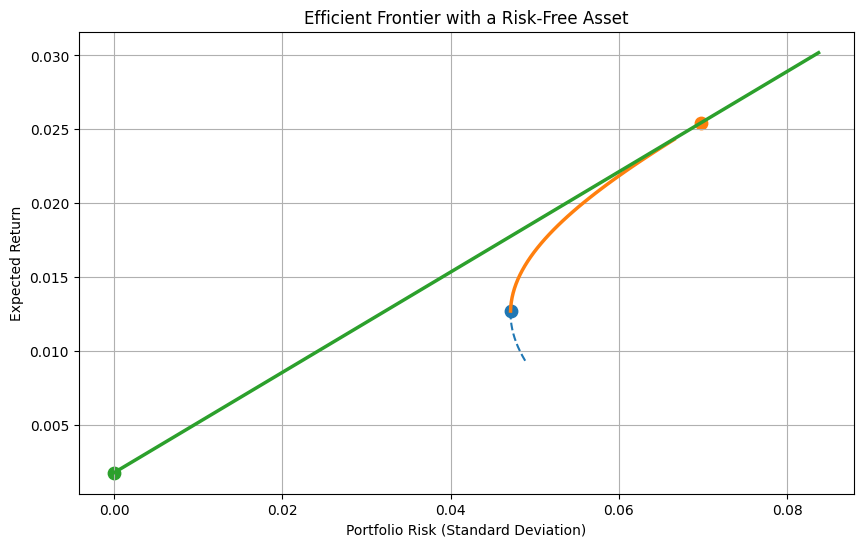

In [ ]:
plt.figure(figsize=(10, 6))

# risky frontier from B.1
plt.plot(inefficient_vols, inefficient_returns, '--', label="Inefficient frontier")
plt.plot(efficient_vols, efficient_returns, linewidth=2.5, label="Efficient frontier (risky assets)")

# capital market line
plt.plot(c1_sigma_road, c1_cml_line, linewidth=2.5, label="Capital Market Line")

# points
plt.scatter(gmv_volatility, gmv_return, s=80, label="GMV portfolio")
plt.scatter(c1_tangent_risk, c1_tangent_return, s=80, label="Tangency portfolio")
plt.scatter(0, safe_month_avg, s=80, label="Risk-free asset")

plt.title("Efficient Frontier with a Risk-Free Asset")
plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()

Once a risk-free asset is introduced, the efficient set is no longer limited to the risky frontier. Instead, it becomes the Capital Market Line, which is tangent to the efficient frontier at the tangency portfolio. This line dominates the original frontier, as it offers higher expected returns for any given level of risk. The tangency portfolio is therefore the key portfolio in this new framework.

In [ ]:
c1_summary_table = pd.DataFrame({
    "Average monthly return": [gmv_return, c1_tangent_return],
    "Monthly standard deviation": [gmv_volatility, c1_tangent_risk]
}, index=["GMV portfolio", "Tangency portfolio"])

print(c1_summary_table)
c1_weight_table = pd.DataFrame({
    "GMV portfolio": gmv_weights,
    "Tangency portfolio": c1_tangent_weights
}, index=Our_return.columns)

print(c1_weight_table)


                    Average monthly return  Monthly standard deviation
GMV portfolio                     0.012703                    0.047128
Tangency portfolio                0.025445                    0.069777
      GMV portfolio  Tangency portfolio
BALL       0.203754           -0.221410
BX        -0.048438            0.069240
ADI        0.083575            0.272694
XYL        0.125423           -0.003429
BRO        0.332128            0.454615
PH        -0.088244            0.482982
PODD       0.027432            0.223468
A          0.086020           -0.165857
EXPD       0.218233           -0.062476
INTC       0.060117           -0.049826


The composition of the tangency portfolio differs significantly from the GMV portfolio. It places larger weights on certain assets and allows for short positions, reflecting a more aggressive strategy aimed at maximizing excess return. In contrast, the GMV portfolio remains more diversified and conservative.


# Question C.2
Find the optimal portfolio along the efficient frontier with the risk-free asset for
an investor with the usual mean-variance utility. Identify such a portfolio for two
different degrees of risk aversion: A = 3, A = 5. Together with the efficient
frontier, plot the optimal portfolios for the two degrees of risk aversion as well as
the corresponding indifference curves. Discuss your results

In [ ]:
# risk aversion levels
risk_lover_lvl = 3
risk_hater_lvl = 5

# share invested in tangency portfolio
share_risk_lover = (c1_tangent_return - safe_month_avg) / (risk_lover_lvl * (c1_tangent_risk ** 2))
share_risk_hater = (c1_tangent_return - safe_month_avg) / (risk_hater_lvl * (c1_tangent_risk ** 2))

# resulting portfolios
risk_lover_return = safe_month_avg + share_risk_lover * (c1_tangent_return - safe_month_avg)
risk_lover_vol = share_risk_lover * c1_tangent_risk

risk_hater_return = safe_month_avg + share_risk_hater * (c1_tangent_return - safe_month_avg)
risk_hater_vol = share_risk_hater * c1_tangent_risk

print("Investor with low risk aversion (A = 3)")
print("Weight in tangency portfolio :", share_risk_lover)
print("Expected return :", risk_lover_return)
print("Risk :", risk_lover_vol)

print("\nInvestor with high risk aversion (A = 5)")
print("Weight in tangency portfolio :", share_risk_hater)
print("Expected return :", risk_hater_return)
print("Risk :", risk_hater_vol)

Investor with low risk aversion (A = 3)
Weight in tangency portfolio : 1.6211329628075037
Expected return : 0.040152491920413154
Risk : 0.11311742952507337

Investor with high risk aversion (A = 5)
Weight in tangency portfolio : 0.9726797776845023
Expected return : 0.02479782848558123
Risk : 0.06787045771504402


The optimal allocation depends directly on the investor’s degree of risk aversion. The aggressive investor (A=3) allocates more than 100% of wealth to the tangency portfolio, which implies borrowing at the risk-free rate in order to leverage the risky portfolio. By contrast, the conservative investor (A=5) allocates a smaller share to the tangency portfolio.

Moreover, the aggressive investor chooses a portfolio with substantially higher expected return, but also much higher risk. On the other hand, the conservative investor selects a less risky portfolio with a lower expected return. This is consistent with mean-variance theory: lower risk aversion leads to a stronger exposure to the risky tangency portfolio.

In [ ]:
# utility levels
utility_risk_lover = risk_lover_return - (risk_lover_lvl / 2) * (risk_lover_vol ** 2)
utility_risk_hater = risk_hater_return - (risk_hater_lvl / 2) * (risk_hater_vol ** 2)

# sigma range
sigma_axis = np.linspace(0, max(c1_sigma_road), 200)

# indifference curves
curve_risk_lover = utility_risk_lover + (risk_lover_lvl / 2) * (sigma_axis ** 2)
curve_risk_hater = utility_risk_hater + (risk_hater_lvl / 2) * (sigma_axis ** 2)

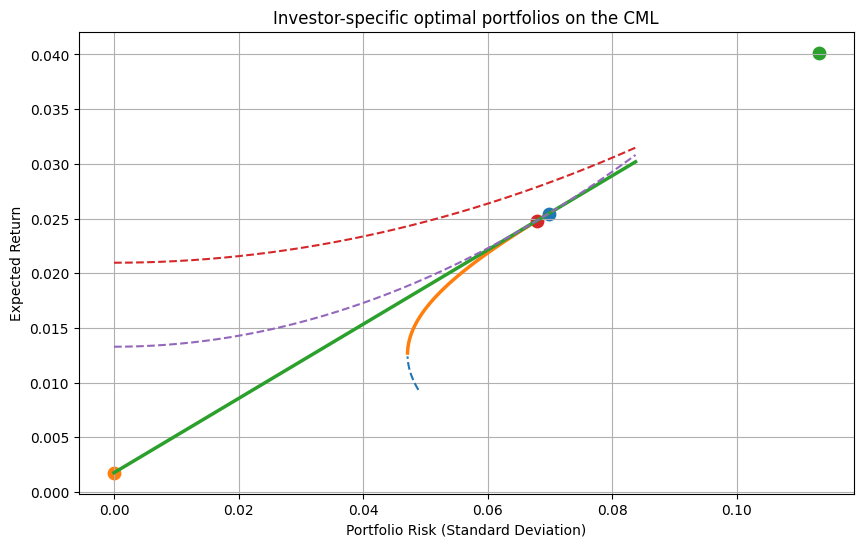

In [ ]:
plt.figure(figsize=(10, 6))

# frontier
plt.plot(inefficient_vols, inefficient_returns, '--', label="Inefficient frontier")
plt.plot(efficient_vols, efficient_returns, linewidth=2.5, label="Efficient frontier")

# CML
plt.plot(c1_sigma_road, c1_cml_line, linewidth=2.5, label="Capital Market Line")

# key points
plt.scatter(c1_tangent_risk, c1_tangent_return, s=80, label="Tangency portfolio")
plt.scatter(0, safe_month_avg, s=80, label="Risk-free asset")

# investor portfolios
plt.scatter(risk_lover_vol, risk_lover_return, s=80, label="Optimal portfolio (A=3)")
plt.scatter(risk_hater_vol, risk_hater_return, s=80, label="Optimal portfolio (A=5)")

# indifference curves
plt.plot(sigma_axis, curve_risk_lover, linestyle='--', label="Indifference (A=3)")
plt.plot(sigma_axis, curve_risk_hater, linestyle='--', label="Indifference (A=5)")

plt.title("Investor-specific optimal portfolios on the CML")
plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()

The graph shows that both optimal portfolios lie on the Capital Market Line, as expected. The aggressive investor is located further to the right, reflecting a higher exposure to risk. By contrast, the conservative investor is closer to the risk-free asset, reflecting a more cautious investment strategy.

In addition, the aggressive investor takes a leveraged position in the tangency portfolio, while the conservative investor remains partially invested in the risk-free asset. The indifference curves confirm that these portfolios are optimal for their respective levels of risk aversion.

# Question D.1

In [ ]:
from sklearn.decomposition import PCA

# Build the price matrix for all stocks in the dataset
all_price_cols = [col for col in df.columns if "_Adj Close" in col]

all_prices = df[all_price_cols].copy()
all_prices.columns = [col.replace("_Adj Close", "") for col in all_price_cols]

# Compute monthly arithmetic returns for all stocks
all_returns = all_prices.pct_change().dropna()

# Keep the sample needed for Part D
returns_apt = all_returns.loc["2016-01-31":"2025-12-31"].copy()

# To make the PCA cleaner, keep only stocks with no missing values
valid_stocks = returns_apt.columns[returns_apt.notna().all()]
returns_apt = returns_apt[valid_stocks]

print("Number of stocks kept for Part D:", len(valid_stocks))

# Split into training and testing periods
train_returns = returns_apt.loc["2016-01-31":"2021-12-31"].copy()
test_returns  = returns_apt.loc["2022-01-31":"2025-12-31"].copy()

print("Training period:", train_returns.index.min().date(), "to", train_returns.index.max().date())
print("Testing period :", test_returns.index.min().date(), "to", test_returns.index.max().date())


# equally weighted return across all available stocks
market_proxy_train = train_returns.mean(axis=1)

# PCA on the training sample only

pca = PCA(n_components=3)
pc_scores = pca.fit_transform(train_returns)

# Store the three principal components in a DataFrame
pc_factors_train = pd.DataFrame(
    pc_scores,
    index=train_returns.index,
    columns=["PC1", "PC2", "PC3"]
)


if pc_factors_train["PC1"].corr(market_proxy_train) < 0:
    pc_factors_train["PC1"] = -pc_factors_train["PC1"]

# Explained variance ratio
explained_variance = pd.Series(
    pca.explained_variance_ratio_,
    index=["PC1", "PC2", "PC3"],
    name="Explained variance ratio"
)

cumulative_explained_variance = explained_variance.cumsum()

print("\nExplained variance ratio:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_explained_variance)

# Correlation of each PC with the market proxy
pc_market_corr = pd.Series({
    "PC1": pc_factors_train["PC1"].corr(market_proxy_train),
    "PC2": pc_factors_train["PC2"].corr(market_proxy_train),
    "PC3": pc_factors_train["PC3"].corr(market_proxy_train)
}, name="Correlation with market proxy")

print("\nCorrelation with the equally weighted market proxy:")
print(pc_market_corr)

# Standardize the series
pc_factors_std = (pc_factors_train - pc_factors_train.mean()) / pc_factors_train.std()
market_proxy_std = (market_proxy_train - market_proxy_train.mean()) / market_proxy_train.std()

Number of stocks kept for Part D: 466
Training period: 2016-02-01 to 2021-12-01
Testing period : 2022-02-01 to 2025-12-01

Explained variance ratio:
PC1    0.333475
PC2    0.104665
PC3    0.051271
Name: Explained variance ratio, dtype: float64

Cumulative explained variance:
PC1    0.333475
PC2    0.438140
PC3    0.489411
Name: Explained variance ratio, dtype: float64

Correlation with the equally weighted market proxy:
PC1    0.985001
PC2    0.046502
PC3   -0.159793
Name: Correlation with market proxy, dtype: float64


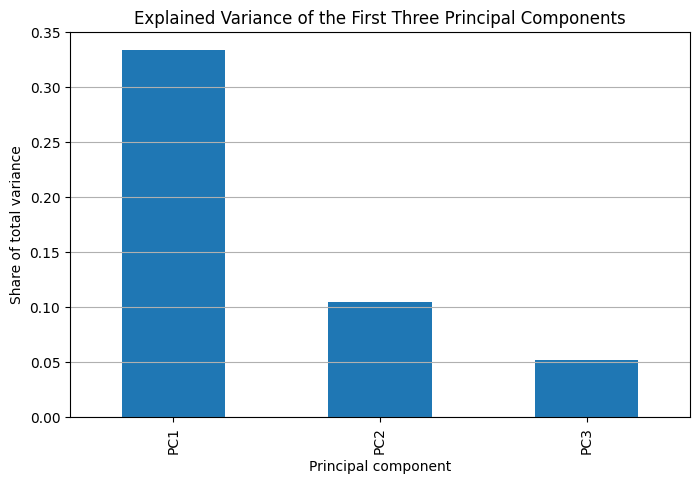

In [ ]:
# Plot explained variance
plt.figure(figsize=(8, 5))
explained_variance.plot(kind="bar")
plt.title("Explained Variance of the First Three Principal Components")
plt.xlabel("Principal component")
plt.ylabel("Share of total variance")
plt.grid(axis="y")
plt.show()

Overall, PC1 explains the largest share of the variance and is the most related to market movements. However, PC2 and PC3 play a more secondary role. we will focus on PC1 as the main factor in the following comparison.

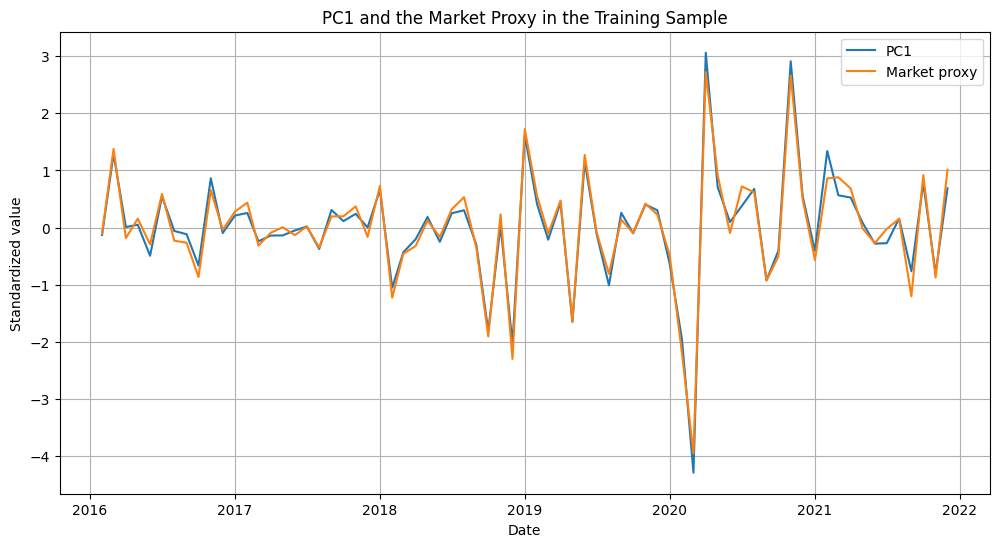

In [ ]:
#Compare PC1 with the equally weighted market proxy
plt.figure(figsize=(12, 6))
plt.plot(pc_factors_std.index, pc_factors_std["PC1"], label="PC1")
plt.plot(market_proxy_std.index, market_proxy_std, label="Market proxy")
plt.title("PC1 and the Market Proxy in the Training Sample")
plt.xlabel("Date")
plt.ylabel("Standardized value")
plt.legend()
plt.grid(True)
plt.show()


We can observe that PC1 and the equally weighted market proxy follow very similar patterns over time, which suggests a strong correlation between the two series. This indicates that PC1 captures a large part of the common variation across stock returns.

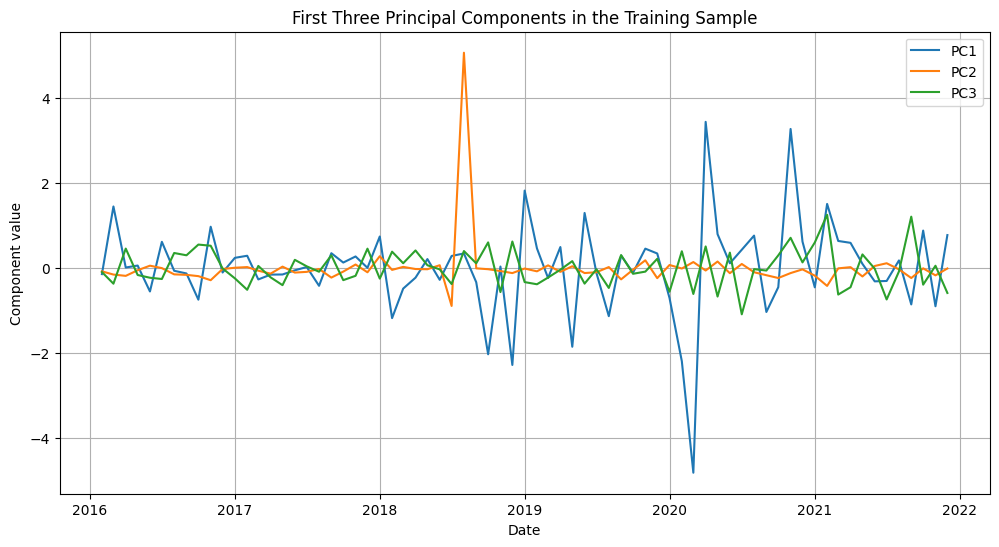

In [ ]:
# Plot the three principal components over time
plt.figure(figsize=(12, 6))
for col in pc_factors_train.columns:
    plt.plot(pc_factors_train.index, pc_factors_train[col], label=col)

plt.title("First Three Principal Components in the Training Sample")
plt.xlabel("Date")
plt.ylabel("Component value")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

This graph shows how the three principal components evolve over time. We can see that PC1 moves more than PC2 and PC3, with bigger ups and downs. PC2 and PC3 stay closer to zero and are more stable. This means that PC1 captures most of the common movements in stock returns, while the other components play a smaller role.

Number of common dates: 71
PC1 shape: (71,)
S&P 500 shape: (71,)

Correlation between PC1 and S&P 500 returns: 0.9442915664447246


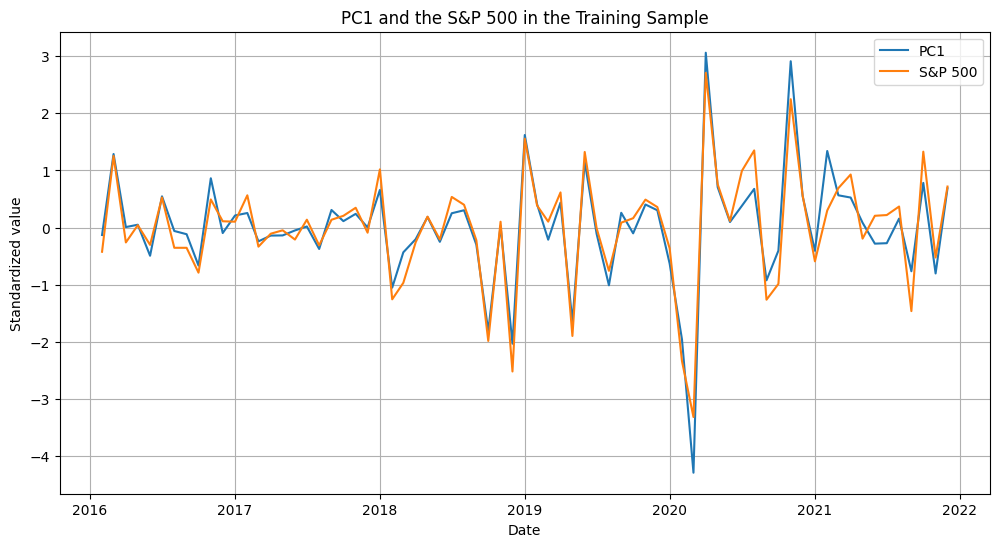

In [ ]:
# we compare with the S&P 500 index if Yahoo Finance works
try:
    sp500_data = yf.download("^GSPC",
                             start="2016-01-01",
                             end="2026-01-01",
                             interval="1mo",
                             auto_adjust=True,
                             progress=False)

    # Keep only one price series
    if "Close" in sp500_data.columns:
        sp500_prices = sp500_data["Close"].copy()
    else:
        sp500_prices = sp500_data.squeeze().copy()

    # Make sure it is a Series
    if isinstance(sp500_prices, pd.DataFrame):
        sp500_prices = sp500_prices.iloc[:, 0]

    sp500_prices.index = pd.to_datetime(sp500_prices.index)
    sp500_prices = sp500_prices.dropna()

    # Compute monthly returns
    sp500_returns = sp500_prices.pct_change().dropna()

    # Keep only the training sample
    sp500_train = sp500_returns.loc["2016-01-31":"2021-12-31"].copy()

    # Align dates with PC1
    common_dates = pc_factors_train.index.intersection(sp500_train.index)
    pc1_aligned = pc_factors_train.loc[common_dates, "PC1"]
    sp500_aligned = sp500_train.loc[common_dates]

    print("Number of common dates:", len(common_dates))
    print("PC1 shape:", pc1_aligned.shape)
    print("S&P 500 shape:", sp500_aligned.shape)

    # Flip sign if needed
    if pc1_aligned.corr(sp500_aligned) < 0:
        pc1_aligned = -pc1_aligned

    pc1_aligned_std = (pc1_aligned - pc1_aligned.mean()) / pc1_aligned.std()
    sp500_aligned_std = (sp500_aligned - sp500_aligned.mean()) / sp500_aligned.std()

    print("\nCorrelation between PC1 and S&P 500 returns:",
          pc1_aligned.corr(sp500_aligned))

    plt.figure(figsize=(12, 6))
    plt.plot(common_dates, pc1_aligned_std, label="PC1")
    plt.plot(common_dates, sp500_aligned_std, label="S&P 500")
    plt.title("PC1 and the S&P 500 in the Training Sample")
    plt.xlabel("Date")
    plt.ylabel("Standardized value")
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print("S&P 500 comparison failed.")
    print("Error:", e)


PC1 and the S&P 500 follow very similar movements over time, with a high correlation. This confirms that PC1 can be seen as a representation of the market factor.

In [ ]:
#Save useful outputs
pc_factors_train.to_csv("D1_pc_factors_training.csv")
explained_variance.to_csv("D1_explained_variance.csv", header=True)
pc_market_corr.to_csv("D1_pc_market_correlation.csv", header=True)

# Question D.2
Equipped with the three PC factors, estimate the factor loadings βˆ
i
for each stock
using only the training sample. Visualize the distributions of the loadings with
respect to each factor

Some examples of estimated factor loadings:
           PC1       PC2       PC3
MMM   0.033271 -0.005306 -0.035110
AOS   0.040541 -0.007827 -0.054393
ABT   0.022379  0.003458 -0.056246
ABBV  0.033283  0.006386 -0.006866
ACN   0.040532  0.011361 -0.043673

Summary statistics of factor loadings:
              PC1         PC2         PC3
count  466.000000  466.000000  466.000000
mean     0.040724    0.003432   -0.016848
std      0.022103    0.046246    0.043198
min     -0.010471   -0.048229   -0.096268
25%      0.027934   -0.008291   -0.045166
50%      0.038391    0.000266   -0.026955
75%      0.050677    0.008995    0.001386
max      0.198431    0.928032    0.184733


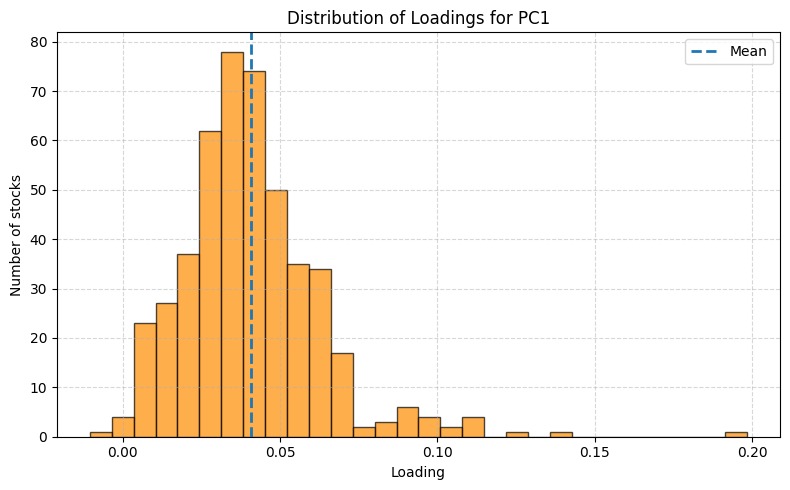

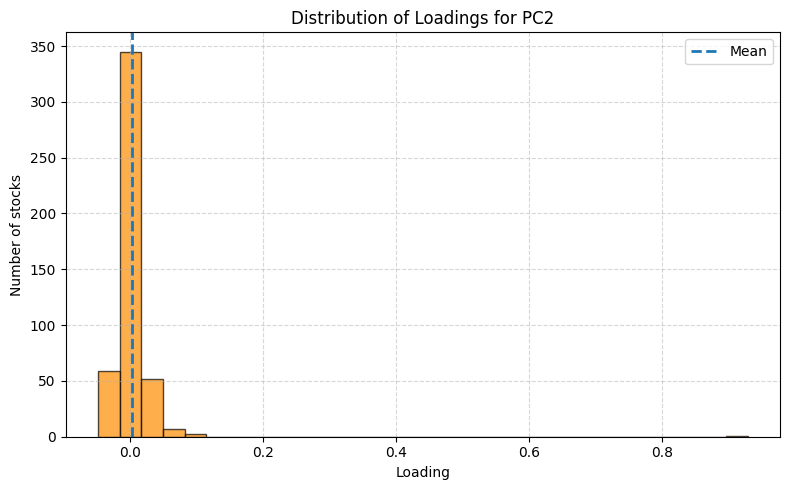

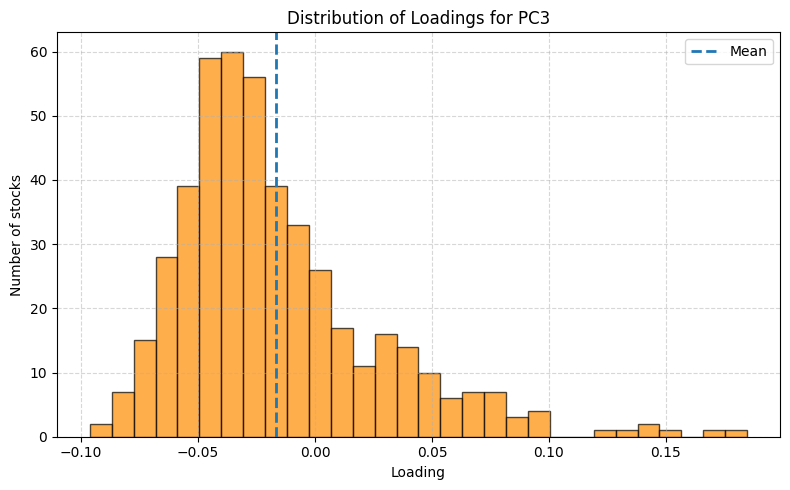

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(pc_factors_train)

# DataFrame to store factor loadings
beta_hat = pd.DataFrame(index=train_returns.columns, columns=["PC1", "PC2", "PC3"])

alpha_hat = pd.Series(index=train_returns.columns, dtype=float)

# Run one time-series regression for each stock
for stock in train_returns.columns:

    y = train_returns[stock]
    model = sm.OLS(y, X).fit()

    alpha_hat.loc[stock] = model.params["const"]
    beta_hat.loc[stock, "PC1"] = model.params["PC1"]
    beta_hat.loc[stock, "PC2"] = model.params["PC2"]
    beta_hat.loc[stock, "PC3"] = model.params["PC3"]

# Convert to numeric
beta_hat = beta_hat.astype(float)

# Display the first rows
print("Some examples of estimated factor loadings:")
print(beta_hat.head())

# Summary statistics
print("\nSummary statistics of factor loadings:")
print(beta_hat.describe())

# Plots for distributions of loadings
for factor in ["PC1", "PC2", "PC3"]:

    data = beta_hat[factor].dropna()

    if len(data) == 0:
        print(f"No data for {factor}")
        continue

    plt.figure(figsize=(8, 5))

    plt.hist(data,
         bins=30,
         edgecolor="black",
         alpha=0.7,
         color="darkorange")

    plt.axvline(data.mean(),
                linestyle="dashed",
                linewidth=2,
                label="Mean")

    plt.title(f"Distribution of Loadings for {factor}")
    plt.xlabel("Loading")
    plt.ylabel("Number of stocks")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

The distributions of the estimated loadings show that most stocks are positively related to PC1, which means that this factor reflects the overall movement of stock returns. PC2 values are mostly close to zero, which suggests that it has a smaller influence. PC3 is more spread out, with both positive and negative values, meaning that its impact differs across stocks. Overall, PC1 seems to be the most important factor.

## D.3 – Construction of factor-neutral zero-cost portfolios

For each portfolio size (N = 10, 50, 100), we randomly select N stocks and generate an initial vector of random weights. We then adjust these weights to satisfy two constraints: (i) zero net investment (sum of weights = 0), and (ii) zero exposure to the three PCA factors estimated in D.2.


In [ ]:
# Reproducibility
np.random.seed(42)

# Portfolio sizes and number of repetitions
portfolio_sizes = [10, 50, 100]
n_simulations = 1000

available_stocks = beta_hat.dropna().index.tolist()

print("Number of available stocks for D.3:", len(available_stocks))


def build_factor_neutral_portfolio(selected_stocks, beta_hat_df):

# Betas of the selected stocks
    B = beta_hat_df.loc[selected_stocks, ["PC1", "PC2", "PC3"]].values
    N = len(selected_stocks)

 # Random initial weights
    w0 = np.random.randn(N)

 # Constraint matrix A
    A = np.vstack([np.ones(N), B.T])

 # Projection formula:
    AA_inv = np.linalg.pinv(A @ A.T)
    w = w0 - A.T @ AA_inv @ A @ w0

    return w

# Store all generated portfolios
d3_portfolios = {}

# Summary table
d3_summary = []

for N in portfolio_sizes:

    weights_list = []
    stocks_list = []

    for sim in range(n_simulations):

# Randomly choose N stocks
        selected_stocks = np.random.choice(available_stocks, size=N, replace=False)

 # Build the zero-cost, factor-neutral portfolio
        w = build_factor_neutral_portfolio(selected_stocks, beta_hat)

        weights_list.append(w)
        stocks_list.append(selected_stocks)

# Quick diagnostic for the first simulation only
        if sim == 0:
            B_check = beta_hat.loc[selected_stocks, ["PC1", "PC2", "PC3"]].values
            exposure_check = w @ B_check
            print(f"\nDiagnostics for N={N}, first portfolio")
            print("Sum of weights:", np.sum(w))
            print("Exposure to PC1, PC2, PC3:", exposure_check)

    d3_portfolios[N] = {
        "stocks": stocks_list,
        "weights": weights_list
    }

    d3_summary.append({
        "Portfolio size N": N,
        "Number of portfolios": len(weights_list)
    })

d3_summary = pd.DataFrame(d3_summary)
print("\nD.3 summary:")
print(d3_summary)

Number of available stocks for D.3: 466

Diagnostics for N=10, first portfolio
Sum of weights: 6.483702463810914e-14
Exposure to PC1, PC2, PC3: [ 2.13544460e-15  2.55438032e-16 -1.65666092e-15]

Diagnostics for N=50, first portfolio
Sum of weights: -3.4365843504247096e-12
Exposure to PC1, PC2, PC3: [-1.41935075e-13  1.85268467e-15  6.47676357e-14]

Diagnostics for N=100, first portfolio
Sum of weights: 1.1546319456101628e-14
Exposure to PC1, PC2, PC3: [ 0.00000000e+00 -9.71445147e-17  5.55111512e-16]

D.3 summary:
   Portfolio size N  Number of portfolios
0                10                  1000
1                50                  1000
2               100                  1000


The diagnostics confirm that the constructed portfolios satisfy the imposed constraints. In all cases, the sum of portfolio weights is extremely close to zero, which ensures that the portfolios are effectively zero-investment. Similarly, the exposures to the three principal component factors are numerically very close to zero, indicating that the portfolios are factor-neutral.

The procedure was successfully repeated 1,000 times for each portfolio size
𝑁= 10,50,100
resulting in a total of 3,000 portfolios. This provides a sufficiently large sample to analyze the distribution of returns in the next step. Since the portfolios are constructed mechanically from random initial weights and are neutral to all considered factors, they are not optimized for performance. This makes them suitable for testing the APT implication that such portfolios should have an expected return close to zero.

## D.4 – Analysis of portfolio returns
For each simulated portfolio, we compute its monthly returns over the testing period. We then calculate the average return of each portfolio and analyze the distribution of these average returns for each portfolio size (N = 10, 50, 100).
Finally, we compute the fraction of portfolios with statistically significant mean returns in order to assess whether the APT prediction holds in practice.

In [ ]:
# Store results
portfolio_mean_returns = {10: [], 50: [], 100: []}
portfolio_tstats = {10: [], 50: [], 100: []}

# Loop over portfolio sizes
for N in [10, 50, 100]:

    stocks_list = d3_portfolios[N]["stocks"]
    weights_list = d3_portfolios[N]["weights"]

    for i in range(len(weights_list)):

        selected_stocks = stocks_list[i]
        w = weights_list[i]

        # test period returns
        returns_subset = test_returns[selected_stocks]

        # Portfolio returns
        port_returns = returns_subset @ w

        # Mean return
        mean_return = port_returns.mean()

        # t-statistic
        std_dev = port_returns.std(ddof=1)
        T = len(port_returns)

        if std_dev > 0:
            t_stat = mean_return / (std_dev / np.sqrt(T))
        else:
            t_stat = 0

        portfolio_mean_returns[N].append(mean_return)
        portfolio_tstats[N].append(t_stat)

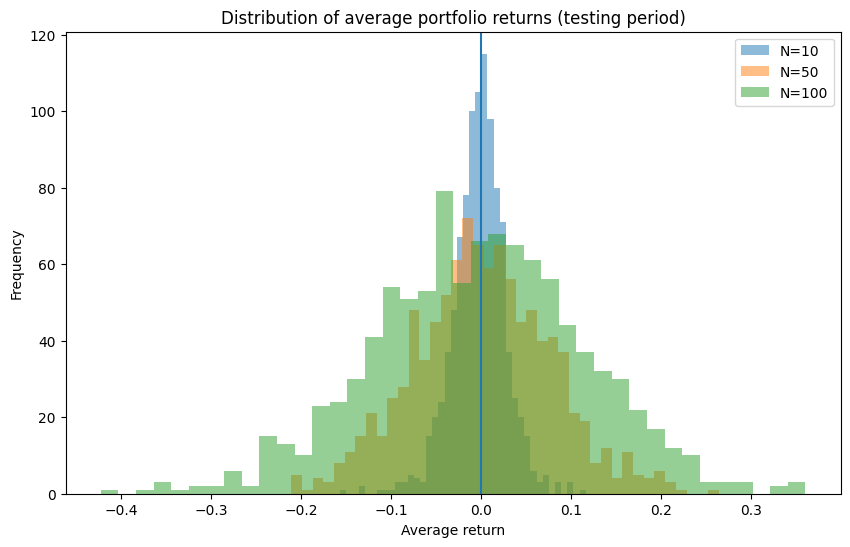

In [ ]:
# Plot distributions

plt.figure(figsize=(10,6))

for N in [10, 50, 100]:
    plt.hist(portfolio_mean_returns[N], bins=40, alpha=0.5, label=f"N={N}")

plt.axvline(0)
plt.title("Distribution of average portfolio returns (testing period)")
plt.xlabel("Average return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The distributions of average portfolio returns are centered around zero for all portfolio sizes, which is consistent with the APT prediction that factor-neutral zero-investment portfolios should not generate abnormal returns.

In [ ]:
# Significance test (5% level, t ≈ 1.96)

results = []

for N in [10, 50, 100]:

    t_stats = np.array(portfolio_tstats[N])

    significant = np.abs(t_stats) > 1.96
    fraction_significant = np.mean(significant)

    results.append({
        "Portfolio size N": N,
        "Fraction significant": fraction_significant
    })

results_df = pd.DataFrame(results)
print(results_df)

   Portfolio size N  Fraction significant
0                10                 0.074
1                50                 0.071
2               100                 0.082


As the portfolio size increases, the dispersion of returns remains relatively wide but becomes slightly more concentrated around zero. This reflects the effect of diversification, as larger portfolios reduce idiosyncratic risk.
The fraction of portfolios with statistically significant average returns is around 7–8% across all portfolio sizes, which is higher than the 5% expected under pure randomness.
This suggests that some portfolios appear to generate abnormal returns. However, this does not necessarily contradict the APT. These results may be driven by estimation errors in the factor loadings, the use of a limited number of factors, or sampling variability.
